# **Previsão de Custos Assistenciais e Otimização de Sinistralidade na Saúde Suplementar**

## **Objetivo e Informações Gerais do Projeto**

* Desenvolvimento de um modelo preditivo de IA e Machine Learning focado na previsão de custos hospitalares (Billing Amount) para otimização do índice de sinistralidade e gestão de risco epidemiológico na saúde suplementar.

### **Informações do Dataset (Dicionário de Dados)**

---

* Dataset sintético contendo 55.500 linhas e 15 colunas, projetado para simular dados reais da área da saúde.
* Cada coluna fornece informações específicas sobre o paciente, sua internação e os serviços de saúde prestados.
* Esta estrutura torna o dataset ideal para tarefas de análise de dados, engenharia de recursos e modelagem preditiva aplicadas ao setor de saúde suplementar e controle de sinistralidade.


| Nome da Coluna | Tipo de Dado | Descrição em Português |
| :--- | :--- | :--- |
| **Name** | object | Nome do paciente associado ao registro de saúde. |
| **Age** | int64 | Idade do paciente no momento da internação, expressa em anos. |
| **Gender** | object | Gênero biológico do paciente. |
| **Blood Type** | object | Tipo sanguíneo do paciente. |
| **Medical Condition** | object | Condição médica principal ou diagnóstico primário do paciente. |
| **Date of Admission** | object | A data em que o paciente foi admitido na unidade de saúde. |
| **Doctor** | object | Nome do médico responsável pelos cuidados do paciente durante a internação. |
| **Hospital** | object | Identifica a instituição de saúde ou hospital onde o paciente foi internado. |
| **Insurance Provider** | object | Operadora de plano de saúde ou provedor de seguro do paciente. |
| **Billing Amount** | float64 | **[Variável Alvo]** O valor total faturado pelos serviços médicos durante a internação. Representa o custo bruto do sinistro. |
| **Room Number** | int64 | Número do quarto/leito onde o paciente ficou acomodado. |
| **Admission Type** | object | Especifica o caráter da internação, refletindo as circunstâncias da admissão. |
| **Discharge Date** | object | A data em que o paciente recebeu alta hospitalar. |
| **Medication** | object | Identifica o medicamento principal prescrito ou administrado durante a internação. |
| **Test Results** | object | Descreve o resultado dos exames médicos diagnósticos realizados. |





## **Etapa 1: EDA**

### Leitura e Análise Inicial dos Dados

In [1]:
# importar as bibliotecas

import pandas as pd
import numpy as np
import os

from IPython.display import Markdown

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# carregar o arquivo .csv e analisar seus componentes

try:
    df = pd.read_csv('healthcare_dataset.csv')
    print(f"✅ Arquivo carregado com sucesso!")
    print('=' * 55)
    print(f"🔍 Visualização das Primeiras Linhas do Dataframe")
    print('=' * 55)
    display(df.head())
    print('=' * 45)
    print(f"ℹ️ Informações do Dataframe")
    print('=' * 45)
    print(df.info())
    print('=' * 45)
    print(f"📊 Estatísticas Descritivas do Dataframe")
    print('=' * 45)
    print(df.describe())
    print('=' * 45)
    print(f"📐 Dimensões do DataFrame")
    print('=' * 45)
    print(f"Número de Linhas: {df.shape[0]}")
    print(f"Número de Colunas: {df.shape[1]}")
except Exception as e:
    print(f"❌ Erro ao ler o arquivo. Detalhes: {e}")

✅ Arquivo carregado com sucesso!
🔍 Visualização das Primeiras Linhas do Dataframe


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


ℹ️ Informações do Dataframe
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), 

In [3]:
# cópia do dataframe original antes da manipulação para segurança
df_original = df.copy()

In [4]:
# === ANÁLISE E TRATAMENTO INICIAL DOS DADOS ===

# --- 1. Padronização da Nomenclatura das Colunas do Dataframe ---
df.columns = df.columns.str.lower().str.replace(' ','_')
print("✅ Padronização da Nomenclatura das Colunas Concluída\n" + '=' * 65)
print(list(df.columns))
print()

# --- 2. Padronização da Coluna 'name' ---
print("✅ Padronização da Colunas 'name' Concluída\n" + '=' * 65)
print(f"* Antes: {df_original['Name'].head(3).tolist()}")
df['name'] = df['name'].str.lower()
print(f"* Depois: {df['name'].head(3).tolist()}")
print()

# --- 3. Transformar as Colunas 'date_of_admission' e 'discharge_date' para Datetima ---
print("✅ Adequação do Tipo de Dados Concluída\n" + '=' * 65)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')
print(f"* Tipagem da Coluna 'date_of_admission': {df['date_of_admission'].dtype}")
print(f"* Tipagem da Coluna 'discharge_date': {df['discharge_date'].dtype}")
print()

# --- 4. Arredondar Valor de 'billing_amount' ---
print("✅ Valor Arredondado .2f para 'billing_amount' Concluída\n" + '=' * 65)
df['billing_amount'] = df['billing_amount'].round(2)
print(df['billing_amount'].head().tolist())
print()

# --- 5. Checagem de Valores Nulos e Duplicados
print("✅ Conferência de Valores Nulos e Duplicados Concluída\n" + '=' * 65)
df_nulos = df.isna().sum().sum()
df_duplicados = df.duplicated().sum()
print(f"Valores Nulos: {df_nulos}")
print(f"Valores Duplicados: {df_duplicados}")

✅ Padronização da Nomenclatura das Colunas Concluída
['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']

✅ Padronização da Colunas 'name' Concluída
* Antes: ['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH']
* Depois: ['bobby jackson', 'leslie terry', 'danny smith']

✅ Adequação do Tipo de Dados Concluída
* Tipagem da Coluna 'date_of_admission': datetime64[ns]
* Tipagem da Coluna 'discharge_date': datetime64[ns]

✅ Valor Arredondado .2f para 'billing_amount' Concluída
[18856.28, 33643.33, 27955.1, 37909.78, 14238.32]

✅ Conferência de Valores Nulos e Duplicados Concluída
Valores Nulos: 0
Valores Duplicados: 534


In [5]:
# === ANÁLISE E TRATAMENTO DE VALORES DUPLICADOS ===

# --- 1. Visualização das linhas 100% duplicadas isoladas ---
print("🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):")
print('=' * 75)

# Filtra apenas as linhas duplicadas para exibição analítica
df_duplicados_completos = df[df.duplicated(keep=False)].sort_values(by='name')
display(df_duplicados_completos.head(6))
print()

# Armazena a quantidade exata de linhas duplicadas antes de dropar
qtd_duplicados = df.duplicated().sum()
formato_original = df.shape

# --- 2. Remoção dos valores duplicados exatos do DataFrame Principal ---
df = df.drop_duplicates()

# Configuração global para exibir o texto completo sem cortes
pd.set_option('display.max_colwidth', None)        # remove o limite de largura das colunas
pd.set_option('display.expand_frame_repr', False)  # impede o Pandas de quebrar as tabelas em linhas secundárias

# --- 3. Conferência e Conclusão da Etapa ---
print("✅ Conferência de Valores Duplicados Dropados Concluída\n" + "=" * 65)
print(f"* Formato original do DataFrame:        {formato_original[0]} linhas e {formato_original[1]} colunas")
print(f"* Quantidade de linhas duplicadas:      {qtd_duplicados}\n" + '-' * 65)
print(f"* Novo formato após o tratamento:       {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"* Validação final (Duplicados atuais):  {df.duplicated().sum()}")

🔍 Análise da amostra de linhas 100% idênticas (Possível erro de sistema):


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
42407,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
54285,abigail young,41,Female,O+,Hypertension,2022-12-15,Edward Kramer,Moore-Mcdaniel,UnitedHealthcare,1983.57,192,Elective,2023-01-13,Ibuprofen,Normal
40385,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
53139,adam thomas,75,Male,O+,Hypertension,2022-01-02,Beverly Miller,Sanchez-Wilson,Cigna,16294.91,180,Urgent,2022-01-30,Ibuprofen,Normal
55298,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal
24779,alex black,51,Male,O+,Diabetes,2022-03-27,Frank Williams,Short and Sons,Aetna,39525.67,246,Emergency,2022-04-21,Aspirin,Normal



✅ Conferência de Valores Duplicados Dropados Concluída
* Formato original do DataFrame:        55500 linhas e 15 colunas
* Quantidade de linhas duplicadas:      534
-----------------------------------------------------------------
* Novo formato após o tratamento:       54966 linhas e 15 colunas
* Validação final (Duplicados atuais):  0


In [6]:
# === ANÁLISE DE VALORES OCULTOS ===

# Verificar os valores únicos de colunas categóricas para identificar se há valores "nulos disfarçados"
print("✅ Conferência de Possíveis Valores Ocultos Concluída\n" + "=" * 65)
for col in ['gender', 'blood_type', 'medical_condition', 'insurance_provider', 'admission_type', 'medication', 'test_results']:
    print(f"* Valores Únicos em {col}: {df[col].unique()}")

✅ Conferência de Possíveis Valores Ocultos Concluída
* Valores Únicos em gender: ['Male' 'Female']
* Valores Únicos em blood_type: ['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']
* Valores Únicos em medical_condition: ['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']
* Valores Únicos em insurance_provider: ['Blue Cross' 'Medicare' 'Aetna' 'UnitedHealthcare' 'Cigna']
* Valores Únicos em admission_type: ['Urgent' 'Emergency' 'Elective']
* Valores Únicos em medication: ['Paracetamol' 'Ibuprofen' 'Aspirin' 'Penicillin' 'Lipitor']
* Valores Únicos em test_results: ['Normal' 'Inconclusive' 'Abnormal']


In [7]:
# === ANÁLISE DE INCONSISTÊNCIAS TEMPORAIS ===

# As datas de alta hospitalar não podem ser anteriores às datas de admissão
inconsistencias_data = df[df['discharge_date'] < df['date_of_admission']]
print("✅ Conferência de Inconsistências Temporais Concluída\n" + '=' * 75)
print(f"Linhas com datas inconsistentes: {inconsistencias_data.shape[0]}")

✅ Conferência de Inconsistências Temporais Concluída
Linhas com datas inconsistentes: 0


In [8]:
# === INVESTIGAÇÃO DE FATURAMENTO NEGATIVO (BILLING AMOUNT < 0) ===

# 1. Filtragem das linhas com valores negativos
df_billing_negativo = df[df['billing_amount'] < 0]

print("🔍 Investigação de Faturamento Negativo:\n" + '=' *65)
print(f"* Quantidade de registros com faturamento negativo: {df_billing_negativo.shape[0]}")
print(f"* Menor valor encontrado: R$ {df_billing_negativo['billing_amount'].min():,.2f}")
print()

# 2. Visualizar uma amostra dessas linhas para entender o padrão
print("\n🔍 Amostra dos registros negativos:\n" + '=' * 65)
display(df_billing_negativo.head(5))

# 3. Análise de Contexto: Investigação de Padrões Associados ao Faturamento Negativo
print("\n📊 Distribuição por Operadora de Saúde (Insurance Provider):\n" + '=' * 65)
print(df_billing_negativo['insurance_provider'].value_counts())

print("\n📊 Distribuição por Tipo de Admissão (Admission Type):\n" + '=' * 65)
print(df_billing_negativo['admission_type'].value_counts())

print("\n📊 Distribuição por Resultado do Teste (Test Results):\n" + '=' * 65)
print(df_billing_negativo['test_results'].value_counts())

🔍 Investigação de Faturamento Negativo:
* Quantidade de registros com faturamento negativo: 106
* Menor valor encontrado: R$ -2,008.49


🔍 Amostra dos registros negativos:


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
132,ashley erickson,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.51,376,Urgent,2019-11-23,Penicillin,Normal
799,christopher weiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.25,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,ashley warner,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.36,426,Elective,2022-01-11,Ibuprofen,Normal
1421,jay galloway,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.10,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,joshua williamson,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.73,369,Urgent,2021-04-17,Aspirin,Abnormal



📊 Distribuição por Operadora de Saúde (Insurance Provider):
insurance_provider
Aetna               27
Cigna               24
Medicare            21
UnitedHealthcare    19
Blue Cross          15
Name: count, dtype: int64

📊 Distribuição por Tipo de Admissão (Admission Type):
admission_type
Urgent       38
Elective     36
Emergency    32
Name: count, dtype: int64

📊 Distribuição por Resultado do Teste (Test Results):
test_results
Inconclusive    39
Abnormal        38
Normal          29
Name: count, dtype: int64


In [9]:
# === REMOÇÃO DE REGISTROS COM FATURAMENTO INCONSISTENTE (NEGATIVO) ===
# Nota de Negócio: Eliminação de ruídos (glosas médicas totais ou erros de sistema),
# que distorceriam a modelagem de custo bruto do sinistro.

# 1. Identificação do volume antes da exclusão
percentual_negativo = (df_billing_negativo.shape[0] / df.shape[0]) * 100
print('=' * 70)
print("🔍 Investigação da Representatividade de Registros Inconsistentes:\n" + '=' * 70)
print(f"Representatividade: {percentual_negativo:.2f}%")
print()

# 2. Aplicando o filtro para manter apenas faturamento estritamente positivo
# Nota de Negócio: Registros negativos (106 linhas) foram tratados como anomalias de sistema 
# (possíveis glosas médicas ou erros de integração) e desconsiderados para fins de modelagem de sinistralidade.
df_clean = df[df['billing_amount'] >= 0].copy()

# 3. Conferência e Conclusão da Etapa
print('=' * 70)
print("✅ Tratamento de Valores Negativos Concluído\n" + '=' * 70)
print(f"* Registros inconsistentes identificados (Glosa/Erro): {df_billing_negativo.shape[0]}")
print(f"* Formato do DataFrame antes do tratamento:            {df.shape[0]} linhas")
print(f"* Novo formato após remoção dos negativos:             {df_clean.shape[0]} linhas")
print(f"* Validação final (registros inconsistentes atual):    {df_clean[df_clean['billing_amount'] < 0].shape[0]}")



🔍 Investigação da Representatividade de Registros Inconsistentes:
Representatividade: 0.19%

✅ Tratamento de Valores Negativos Concluído
* Registros inconsistentes identificados (Glosa/Erro): 106
* Formato do DataFrame antes do tratamento:            54966 linhas
* Novo formato após remoção dos negativos:             54860 linhas
* Validação final (registros inconsistentes atual):    0


### Feature Engineering

In [10]:
# Criação da pasta 'plots' para armazenar os gráficos gerados pelo projeto
os.makedirs("plots", exist_ok=True)

In [11]:
# === FEATURE ENGINEERING: TEMPO DE INTERNAÇÃO (DIAS) ===

# --- 1. Criação da feature 'length_of_stay' (Dias de Internação)
# Nota de Negócio: Geração do indicador de Tempo de Internação, um dos 
# principais drivers de custo e severidade do sinistro na saúde complementar.
df_clean['length_of_stay'] = (df_clean['discharge_date'] - df_clean['date_of_admission']).dt.days
print("✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'lengh_of_stay'\n" + '=' * 85)


print("🔍 Análise das primeiras linhas da nova feature:")
print('=' * 85)
display(df_clean[['date_of_admission', 'discharge_date', 'length_of_stay']].head())

# --- 2. Análise Descritiva da Nova Variável
print('=' * 60)
print("📊 Resumo estatístico do tempo de internação (em dias):\n" + '=' * 60)
print(df_clean['length_of_stay'].describe())

✅ Criação de Feature de Contagem de Dias de Internação Concluída: 'lengh_of_stay'
🔍 Análise das primeiras linhas da nova feature:


,date_of_admission,discharge_date,length_of_stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


📊 Resumo estatístico do tempo de internação (em dias):
count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64


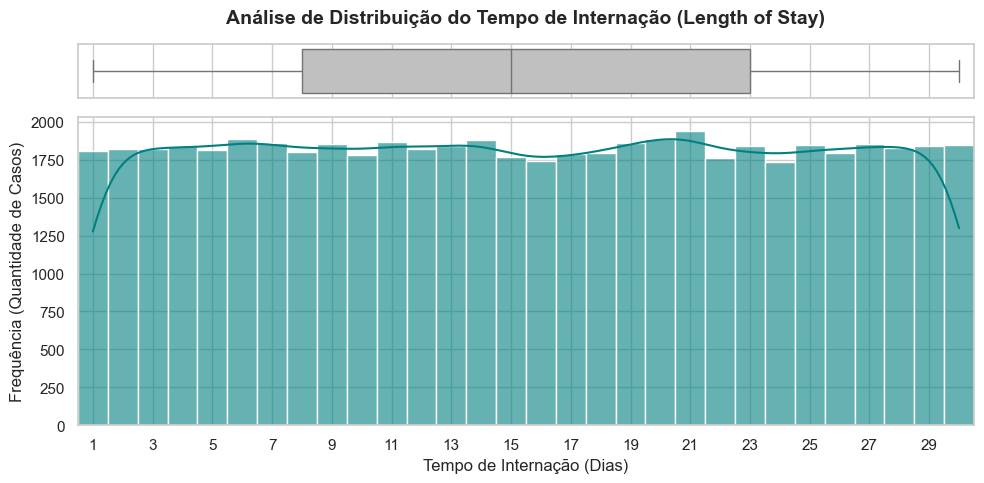

In [12]:
# --- 3. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
sns.set_theme(style="whitegrid")

# Criação da figura com 2 subplots empilhados (Boxplot em cima, Histograma embaixo)
# O argumento 'sharex=True' garante que os eixos X fiquem adequadamente alinhados
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(10, 5), 
    sharex=True,
    gridspec_kw={"height_ratios": (.15, .85)}  # permite mais espaço para o histograma
)

# Plot do Boxplot no topo
sns.boxplot(x=df_clean['length_of_stay'], ax=ax_box, color='silver')
ax_box.set(xlabel='') # remove o rótulo do X superior para não duplicar texto
ax_box.set_title('Análise de Distribuição do Tempo de Internação (Length of Stay)', fontsize=14, pad=15, fontweight='bold')

# Plot do Histograma com a linha KDE embaixo
sns.histplot(
    data=df_clean, 
    x='length_of_stay', 
    kde=True, 
    discrete=True,  # garante o alinhamento de barra por dia (1 a 30)
    color='teal', 
    alpha=0.6,
    ax=ax_hist
)
ax_hist.set_xlabel('Tempo de Internação (Dias)', fontsize=12)
ax_hist.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajuste fino do limite do eixo X baseado no range real dos dias (1 a 30)
ax_hist.set_xlim(0.5, 30.5)
ax_hist.set_xticks(range(1, 31, 2)) # Exibe os dias de 2 em 2 para melhor leitura

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/1_tempo_de_internacao_combinado.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'length_of_stay' (Tempo de Permanência)`**

* Histograma: formato retangular (bloco contínuo) confirma visualmente que o tempo de internação segue uma distribuição uniforme do volume de casos.
* Boxplot: a linha da mediana está cravada exatamente no centro da caixa (15.5 dias), o primeiro quartil ($Q_1$) está em 8 dias e o terceiro quartil ($Q_3$) em 23 dias.

* **`Nota Técnica:`** a ausência de assimetria e de outliers nessa métrica isolada reitera a necessidade de executar a engenharia de features, para combinar o faturamento a outras métricas para extrair o real comportamento de severidade e risco da carteira.

* **`Insight de Negócio:`** sob a ótica de gestão de recursos e auditoria, há claramente uma distribuição uniforme significa e previsibilidade total de ocupação. A operadora tem uma taxa de giro de leitos constante.

✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'
📊 Validação da conversão monetária:
   billing_amount  billing_amount_br
0        18856.28           94281.40
1        33643.33          168216.65
2        27955.10          139775.50
3        37909.78          189548.90
4        14238.32           71191.60
------------------------------------------------------------
* Média de custos por internação (em Dólar - $): 25594.63
* Média de custos por internação (em Real - R$): 127973.17
------------------------------------------------------------
* Valor Mínimo (em R$): 46.20
* Valor Máximo (em R$): 263821.40


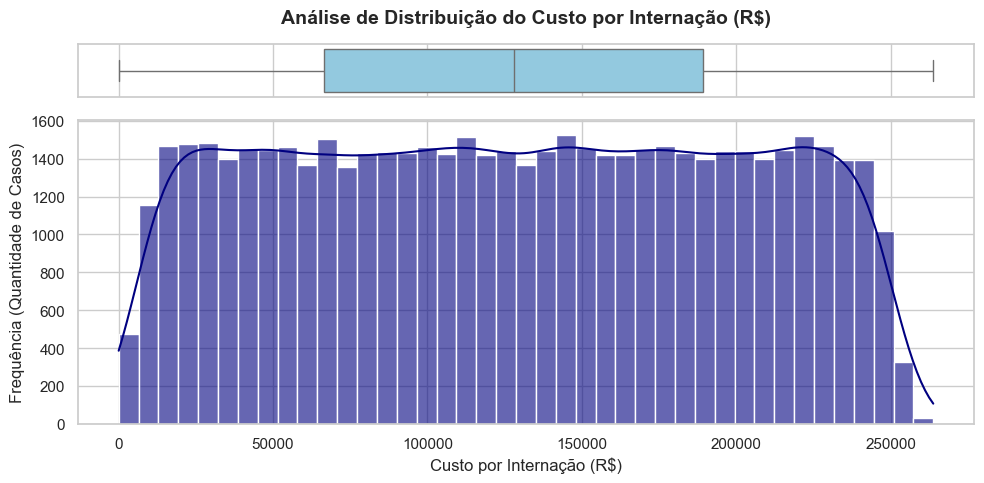

In [13]:
# === FEATURE ENGINEERING: CUSTO POR INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da feature 'billing_amount_br' conversão de dólar para real (Moeda Brasileira)
# Nota de Negócio: a conversão irá trazer maior tangibilidade para o modelo, 
# conforme a realidade brasileira.

# --- 2. Definição da taxa de câmbio de referência
taxa_cambio = 5.00  # Ajuste para a taxa média de fechamento do período do dataset

# --- 3. Criação da nova coluna da nova feature
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount'] * taxa_cambio

# --- 4. Arredondando para duas casas decimais
df_clean.loc[:, 'billing_amount_br'] = df_clean['billing_amount_br'].round(2)

# --- 5. Conferência da Nova Variável

print("✅ Criação de Feature de Conversão de Moeda Dólar para Real Concluída: 'billing_amount_br'\n" + '=' * 90)
print(f"📊 Validação da conversão monetária:\n" + '=' * 90)
print(df_clean[['billing_amount', 'billing_amount_br']].head())
print('-' * 60)
print(f"* Média de custos por internação (em Dólar - $): {df_clean['billing_amount'].mean():.2f}")
print(f"* Média de custos por internação (em Real - R$): {df_clean['billing_amount_br'].mean():.2f}")
print('-' * 60)
print(f"* Valor Mínimo (em R$): {df_clean['billing_amount_br'].min():.2f}")
print(f"* Valor Máximo (em R$): {df_clean['billing_amount_br'].max():.2f}")

# --- 6. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 2 subplots empilhados (Boxplot em cima, Histograma embaixo)
# O argumento 'sharex=True' garante que os eixos X fiquem adequadamente alinhados
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, 
    figsize=(10, 5), 
    sharex=True, 
    gridspec_kw={"height_ratios": (.15, .85)} # permite mais espaço para o histograma
)

# Plot do Boxplot no topo
sns.boxplot(x=df_clean['billing_amount_br'], ax=ax_box, color='skyblue')
ax_box.set(xlabel='') # remove o rótulo do X superior para não duplicar texto
ax_box.set_title('Análise de Distribuição do Custo por Internação (R$)', fontsize=14, pad=15, fontweight='bold')

# Plot do Histograma com a linha KDE embaixo
sns.histplot(
    data=df_clean, 
    x='billing_amount_br', 
    kde=True, 
    ax=ax_hist, 
    color='navy', 
    alpha=0.6
)
ax_hist.set_xlabel('Custo por Internação (R$)', fontsize=12)
ax_hist.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/2_custo_por_internacao_combinado.png', dpi=300, bbox_inches='tight')
plt.show()


**`Análise da Feature: 'billing_amount_br' (Custo por Internação - R$)`**

* Histograma: as barras mantêm praticamente a mesma altura (em torno de 1.400 casos). A linha de densidade (KDE) é quase uma linha reta horizontal no topo (histograma plano).
* Boxplot: a linha da mediana está exatamente no centro da caixa azul (por volta de R$ 128.000), os quartis possuem larguras idênticas e os "bigodes" têm o mesmo comprimento, sem a presença de nenhum outlier.

* **`Nota Técnica:`** a ausência de assimetria e de outliers nessa métrica isolada reitera a necessidade de executar a engenharia de features, para combinar o faturamento a outras métricas para extrair o real comportamento de severidade e risco da carteira.

In [14]:
# === FEATURE ENGINEERING: CUSTO DIÁRIO DE INTERNAÇÃO (EM REAL - R$) ===

# --- 1. Criação da Feature para Análise do Custo Diário em Reais (cost_per_day_br)
# Nota de Negócio: a proposta é normalizar o custo pelo tempo
# Nota Técnica: 'billing_amount_br' dividido pelo tempo de internação ('length_of_stay')

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'cost_per_day_br'] = df_clean['billing_amount_br'] / df_clean['length_of_stay']

# --- 3. Arredondando para duas casas decimais para manter o padrão monetário
df_clean.loc[:, 'cost_per_day_br'] = df_clean['cost_per_day_br'].round(2)

print("✅ Criação da Feature 'cost_per_day_br' Concluída")
print('=' * 80)

# --- 4. Análise Descritiva da Nova Variável
print("📊 Resumo estatístico do custo diário (em R$):")
print('-' * 80)
print(df_clean['cost_per_day_br'].describe())
print('=' * 80)

# Visualização das primeiras linhas para conferência de sanidade
print("\n🔍 Amostra das variáveis financeiras cruzadas:")
print('-' * 80)
print(df_clean[['length_of_stay', 'billing_amount_br', 'cost_per_day_br']].head())

✅ Criação da Feature 'cost_per_day_br' Concluída
📊 Resumo estatístico do custo diário (em R$):
--------------------------------------------------------------------------------
count     54860.000000
mean      16995.664895
std       29007.171947
min           4.750000
25%        4299.507500
50%        8264.670000
75%       16060.707500
max      261059.250000
Name: cost_per_day_br, dtype: float64

🔍 Amostra das variáveis financeiras cruzadas:
--------------------------------------------------------------------------------
   length_of_stay  billing_amount_br  cost_per_day_br
0               2           94281.40         47140.70
1               6          168216.65         28036.11
2              15          139775.50          9318.37
3              30          189548.90          6318.30
4              20           71191.60          3559.58


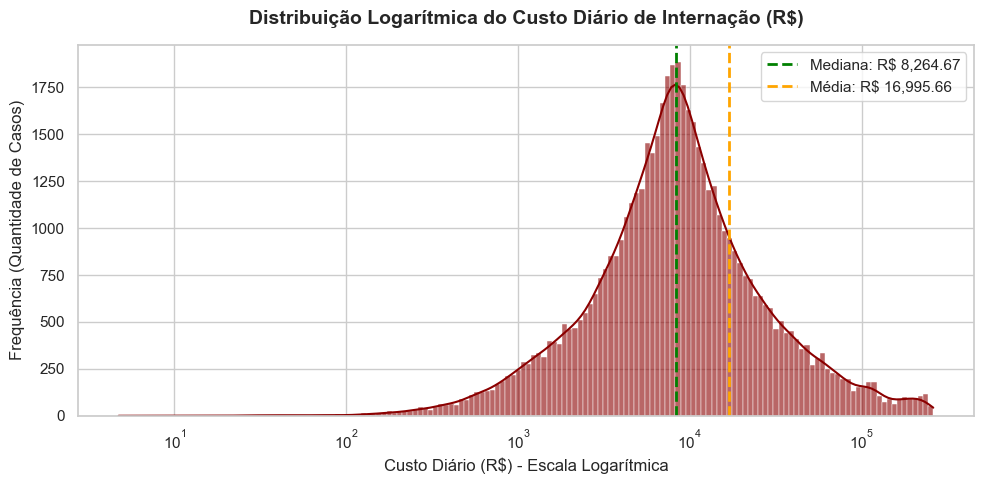

In [15]:
# --- 4. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Plot do Histograma com Escala Logarítmica
sns.histplot(
    data=df_clean, 
    x='cost_per_day_br', 
    kde=True, 
    log_scale=True,  # ideal para lidar com a assimetria e o máximo de R$ 261k
    color='darkred', # cor que remete a custo/criticidade
    alpha=0.6,
    ax=ax
)

# Adicionando linhas verticais para marcar os principais pontos estatísticos (Métricas de Negócio)
mediana = df_clean['cost_per_day_br'].median()
media = df_clean['cost_per_day_br'].mean()

ax.axvline(mediana, color='green', linestyle='--', linewidth=2, label=f'Mediana: R$ {mediana:,.2f}')
ax.axvline(media, color='orange', linestyle='--', linewidth=2, label=f'Média: R$ {media:,.2f}')

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição Logarítmica do Custo Diário de Internação (R$)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Frequência (Quantidade de Casos)', fontsize=12)

# Ativação da legenda das linhas de média e mediana
ax.legend(fontsize=11, loc='upper right')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/3_custo_diario_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'cost_per_day_br' (Custo Diário de Internação - R$)`**

* A Mediana (Linha Verde - R$ 8.264,67): mostra que exatamente metade das diárias de internação custa menos que esse valor, e a outra metade custa mais. Ela representa o "comportamento típico" do segurado comum. <br>
* A Média (Linha Laranja - R$ 16.995,66): esta foi puxada para a direita e é mais que o dobro da mediana.

* **`Nota Técnica:`** a utilização do Histograma com Escala Logarítmica no eixo X aliado ao KDE permite "trazer para perto" os valores gigantescos e otimizar a visualização dos dados. Istou permite analisar a distribuição real tanto dos custos pequenos/médios quanto dos casos catastróficos (altíssimo custo) no mesmo gráfico.

* **`Insight de Negócio:`** Comprovação do impacto dos sinistros de alto custo. Poucos pacientes (a cauda longa à direita) gastam tanto que conseguem distorcer a média de custos de toda a operadora.

In [16]:
# === FEATURE ENGINEERING: AGRUPAMENTO EM FAIXAS DE IDADE (RN 563, ANS) ===

# --- 1. Criação da Feature 'age_group'
# Nota de Negócio: Definição dos limites (bins) e rótulos (labels), conforme a RN 563 da ANS.
# Nota Técnica: O primeiro bin começa em -1 para incluir a idade 0,
# limitado ao teto biológico realista de 120 anos.
bins_ans = [-1, 18, 23, 28, 33, 38, 43, 48, 53, 58, 120]

# --- 2. Criação da lista de rótulos para nomear as fronteiras de idade (bins)
labels_ans = [
    '0 a 18 anos',   '19 a 23 anos',  '24 a 28 anos',  '29 a 33 anos',  '34 a 38 anos',
    '39 a 43 anos',  '44 a 48 anos',  '49 a 53 anos',  '54 a 58 anos',  '59 anos ou mais'
]

# pd.cut encaixa as idades correspondentes conforme a lista da variável labels_ans
df_clean.loc[:, 'age_group'] = pd.cut(df_clean['age'], bins=bins_ans, labels=labels_ans)

print("✅ Criação da Feature 'age_group' (Padrão ANS) Concluída")
print('=' * 80)

# --- 3. Análise Descritiva da Distribuição da Carteira
print("📊 Distribuição de Frequência por Faixa Etária:")
print('=' * 80)
contagem = df_clean['age_group'].value_counts().sort_index()
proporcao = df_clean['age_group'].value_counts(normalize=True).sort_index() * 100

# .zip une as 3 informações em uma única linha para cada loop
for faixa, qtd, prop in zip(contagem.index, contagem.values, proporcao.values):
    print(f"* {faixa:<16} | Beneficiários: {qtd:<6} | Representatividade: {prop:.2f}%")
print('-' * 80)

# --- 4. Cruzamento Estratégico: Custo Médio e Tempo de Internação por Faixa Etária
print("\n📊 Distribuição de Internação e Custos por Faixa Etária (Média):")
print('=' * 80)
analise_sinistro = df_clean.groupby(                             # separa o df nos 10 subgrupos de faixa etária
    'age_group', observed=False)[                                # garante que se a linha estiver vazia, aparecerá no print
    ['length_of_stay', 'billing_amount_br', 'cost_per_day_br']   # filtra para calcular as métricas apenas dessas três colunas
    ].mean().round(2)                                            # calcula o valor médio e arredonda em duas casas decimais                      
print(analise_sinistro)

✅ Criação da Feature 'age_group' (Padrão ANS) Concluída
📊 Distribuição de Frequência por Faixa Etária:
* 0 a 18 anos      | Beneficiários: 885    | Representatividade: 1.61%
* 19 a 23 anos     | Beneficiários: 3938   | Representatividade: 7.18%
* 24 a 28 anos     | Beneficiários: 3987   | Representatividade: 7.27%
* 29 a 33 anos     | Beneficiários: 3906   | Representatividade: 7.12%
* 34 a 38 anos     | Beneficiários: 4224   | Representatividade: 7.70%
* 39 a 43 anos     | Beneficiários: 3929   | Representatividade: 7.16%
* 44 a 48 anos     | Beneficiários: 4014   | Representatividade: 7.32%
* 49 a 53 anos     | Beneficiários: 4067   | Representatividade: 7.41%
* 54 a 58 anos     | Beneficiários: 4205   | Representatividade: 7.66%
* 59 anos ou mais  | Beneficiários: 21705  | Representatividade: 39.56%
--------------------------------------------------------------------------------

📊 Distribuição de Internação e Custos por Faixa Etária (Média):
                 length_of_stay  billing

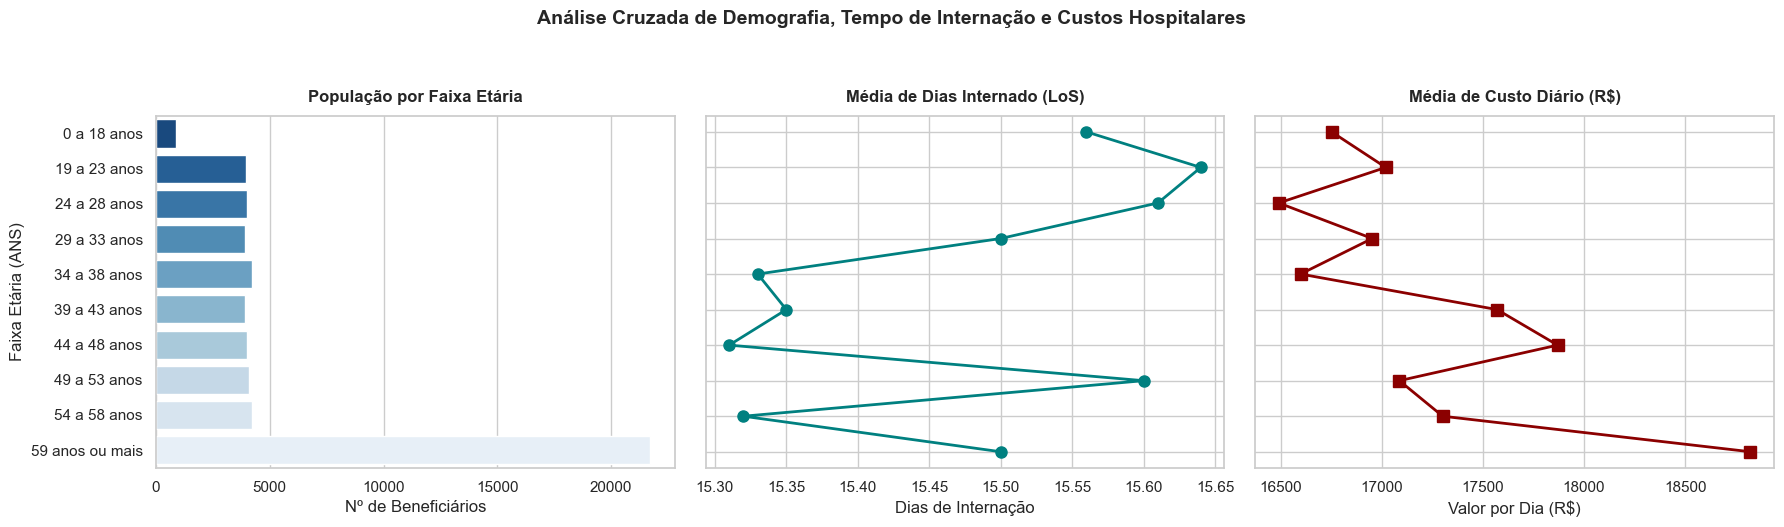

In [17]:
# --- 5. Visualização dos Dados
# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Criação da figura com 1 linha e 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Preparação dos dados agregados para facilitar o plot
df_plot = analise_sinistro.reset_index()
# Adição da contagem de beneficiários ao df_plot para centralizar os dados
df_plot['qtd_beneficiarios'] = df_clean['age_group'].value_counts().sort_index().values

# --- PLOT 1: Quantidade de Beneficiários (Barras) ---
sns.barplot(
    data=df_plot, 
    x='qtd_beneficiarios', 
    y='age_group', 
    ax=axes[0], 
    palette='Blues_r',
    hue='age_group',    # define a cor baseada na própria faixa etária
    legend=False        # remove a legenda repetida que o hue cria automaticamente
)
axes[0].set_title('População por Faixa Etária', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Nº de Beneficiários')
axes[0].set_ylabel('Faixa Etária (ANS)')

# --- PLOT 2: Média de Tempo de Permanência (Linha com Marcador) ---
axes[1].plot(df_plot['length_of_stay'], df_plot['age_group'], marker='o', color='teal', linewidth=2, markersize=8)
axes[1].set_title('Média de Dias Internado (LoS)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Dias de Internação')
axes[1].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# --- PLOT 3: Média de Custo Diário (Linha com Marcador) ---
axes[2].plot(df_plot['cost_per_day_br'], df_plot['age_group'], marker='s', color='darkred', linewidth=2, markersize=8)
axes[2].set_title('Média de Custo Diário (R$)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_xlabel('Valor por Dia (R$)')
axes[2].set_yticklabels([]) # remove rótulos repetidos do eixo Y

# Título Geral da Figura
plt.suptitle('Análise Cruzada de Demografia, Tempo de Internação e Custos Hospitalares', fontsize=14, fontweight='bold', y=1.05)

# Ajustes finais de layout e salvamento seguro
plt.tight_layout()
plt.savefig('plots/4_faixa_etaria_analise_cruzada.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'age_group' (Agrupamento em Faixas de Idade - RN 563, ANS)`**

* População por faixa etária: concentração dos clientes com 59 anos ou mais.<br>
* O tempo de internação varia minimamente entre 15.30 e 15.65 dias, e o custo diário varia entre R$ 16.500 e R$ 18.800. <br>

* **`Nota Técnica:`** as oscilações que parecem "picos e vales" nos gráficos de linha são, na verdade, microvariações geradas sem impacto significativo para o modelo ou diagnóstico do perfil do cliente.

* **`Nota Técnica:`** embora a operadora enfrente um desafio demográfico severo, com uma concentração massiva de beneficiários na faixa de 59 anos ou mais (39.56%), o consumo de recursos hospitalares não é ditado pela idade cronológica. O tempo de permanência e o custo diário médio são homogêneos entre as gerações. Isso prova que o risco atuarial e a sinistralidade desta carteira são governados pela gravidade clínica individual e não pelo envelhecimento da base. <br>

* **`Insight de Negócio:`** com quase 40% da carteira concentrada no grupo de 59 anos ou mais, as operadoras enfrentam um risco severo de descapitalização futura, dado que a sinistralidade crônica dessa população tende a se manifestar no ecossistema de saúde geral. <br>



In [18]:
# === FEATURE ENGINEERING: ATENDIMENTO DE DIA DE SEMANA (0/1) ===

# --- 1. Criação da Feature 'is_weekend_admission'
# Nota de Negócio: Hospitais operam em regime de plantão, exames podem demorar para serem liberados, 
# e a equipe médica de retaguarda costuma cobrar taxas diferenciadas
# Nota Técnica: Variável binária que indica se o paciente deu entrada no hospital no sábado ou no domingo,
# Criação de Flag de Admissão no Final de Semana (Sábado = 5, Domingo = 6)

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_weekend_admission'] = (df_clean['date_of_admission'].dt.weekday >= 5).astype(int)

# --- 3. Análise Descritiva da Nova Variável
print("✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída\n" + '=' * 70)
print((df_clean['is_weekend_admission']).value_counts())

print("\n📊 Distribuição do Dia de Internação (0/1) por Custos Diários (Média):\n" + '=' * 70)
print(df_clean.groupby('is_weekend_admission')[['cost_per_day_br']].mean().round(2))

✅ Criação da Feature 'is_weekend_admission' (Padrão ANS) Concluída
is_weekend_admission
0    39212
1    15648
Name: count, dtype: int64

📊 Distribuição do Dia de Internação (0/1) por Custos Diários (Média):
                      cost_per_day_br
is_weekend_admission                 
0                            17060.34
1                            16833.59


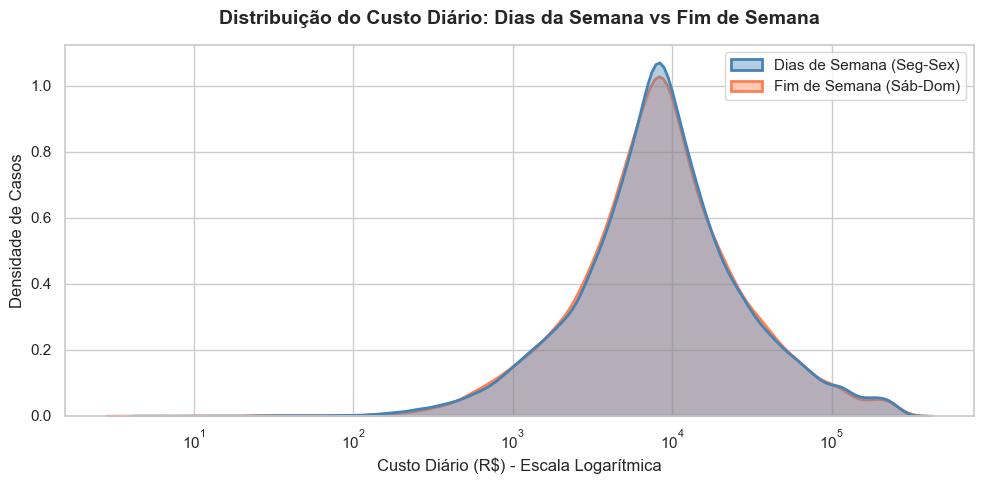

In [19]:
# --- 4. Visualização dos Dados

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot das curvas de densidade para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_weekend_admission',
    fill=True,
    common_norm=False, # garante que as áreas sejam proporcionais ao seu próprio grupo
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2,
    log_scale=True, # mantém a consistência com a escala logarítmica
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Dias da Semana vs Fim de Semana', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title(False)
for t, label in zip(legend.get_texts(), ["Dias de Semana (Seg-Sex)", "Fim de Semana (Sáb-Dom)"]):
    t.set_text(label)

plt.tight_layout()
plt.savefig('plots/5_casos_dias_da_semana_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'is_weekend_admission' (Atendimento de Dia de Semana - 0/1)`**

* As curvas azul (Dias de Semana) e laranja (Fim de Semana) se sobrepõem de forma quase milimétrica. <br>

* **`Nota Técnica:`** a utilização da Escala Logarítmica permite "normalizar" os valores altíssimos e otimizar a visualização dos dados.

* **`Nota Técnica:`** No mercado de saúde, existe uma tese forte de que internações que começam no sábado ou domingo são mais ineficientes e caras (menos médicos de rotina, exames parados, taxas de plantão). Esse gráfico derruba essa tese para a sua base de dados. <br>

* **`Nota Técnica:`** Na extremidade direita do gráfico, ambas as curvas fazem uma pequena oscilação antes de encerar no zero. Isso mostra que a ocorrência de sinistros catastróficos de alto custo acontece na mesma proporção e com a mesma intensidade, em qualquer dia da semana. <br>

In [20]:
# === FEATURE ENGINEERING: TEMPO PROLONGADO DE INTERNAÇÃO (0/1) ===

# --- 1. Criação da Feature 'is_long_stay'
# Nota de Negócio: Internações prolongadas tendem a ter procedimentos mais onerosos ao plano
# Nota Técnica: Criação de Flag de Internação Prolongada (acima do percentil 75% que é 23 dias)

# --- 2. Criação da nova coluna da nova feature
df_clean.loc[:, 'is_long_stay'] = (df_clean['length_of_stay'] > 23).astype(int)

print("✅ Criação da Feature 'is_long_stay' Concluída\n" + '=' * 80)
print((df_clean['is_long_stay']).value_counts().round(2))

print("\n📊 Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):\n" + '=' * 80)
print(df_clean.groupby('is_long_stay')[['cost_per_day_br']].mean().round(2))

✅ Criação da Feature 'is_long_stay' Concluída
is_long_stay
0    42104
1    12756
Name: count, dtype: int64

📊 Distribuição de Internação Prolongada (0/1) por Custos  Diários (Média):
              cost_per_day_br
is_long_stay                 
0                    20706.34
1                     4747.77


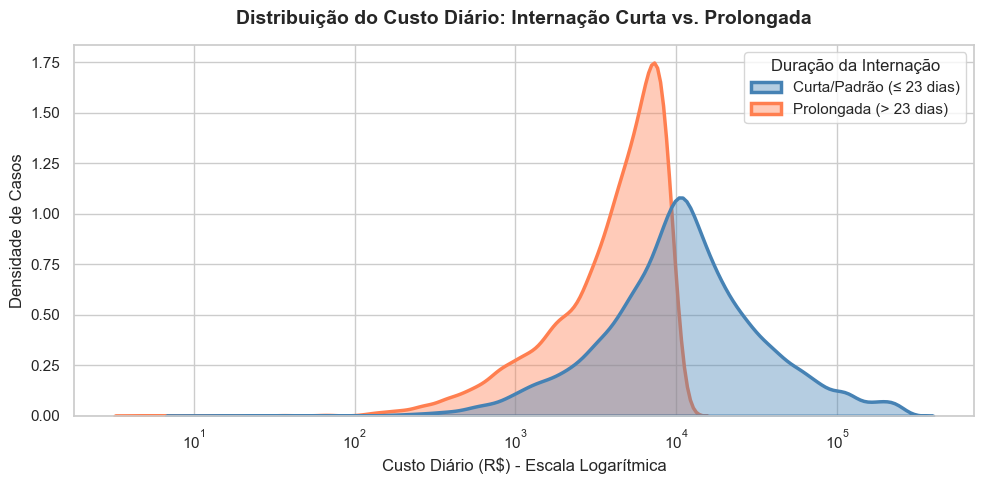

In [21]:
# --- 3. Visualização dos Dados

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 5))

# Plo das curvas de densidade suavizadas para os dois grupos
sns.kdeplot(
    data=df_clean,
    x='cost_per_day_br',
    hue='is_long_stay',
    fill=True,
    common_norm=False,  # normaliza cada grupo individualmente para equilibrar os tamanhos das áreas
    palette={0: 'steelblue', 1: 'coral'},
    alpha=0.4,
    linewidth=2.5,
    log_scale=True,     # aplica o log no eixo X
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Distribuição do Custo Diário: Internação Curta vs. Prolongada', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Custo Diário (R$) - Escala Logarítmica', fontsize=12)
ax.set_ylabel('Densidade de Casos', fontsize=12)

# Customização da legenda para termos termos claros de negócio
legend = ax.get_legend()
legend.set_title("Duração da Internação")
for t, label in zip(legend.get_texts(), ["Curta/Padrão (≤ 23 dias)", "Prolongada (> 23 dias)"]):
    t.set_text(label)

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/6_casos_tempo_internação_log.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'is_long_stay' (Tempo Prolongado de Internação - 0/1)`**

* A curva das internações prolongadas (laranja) possui uma variância visivelmente menor e um pico (moda) deslocado para a esquerda, enquanto a curva das internações curtas (azul) é muito mais dispersa, estendendo-se até a cauda de altíssimo custo.

* **`Nota Técnica:`** * a utilização da Escala Logarítmica permite "normalizar" os valores altíssimos e otimizar a visualização dos dados.

* **`Insight de Negócio:`** para a operadora de saúde, as internações curtas (azul) representam risco de volatilidade financeira de curto prazo, pois contêm os picos de custo diário que ultrapassam R$ 100.000. Esse comportamento é típico de eventos agudos de alta complexidade, exigindo auditoria médica rigorosa e negociação prévia de pacotes cirúrgicos com a rede credenciada para mitigar o risco de tabelas abertas (fee-for-service).

* **`Insight de Negócio:`** os custos mais críticos e agressivos (cirurgia, UTI inicial, exames complexos, órteses e próteses) acontecem no início da internação. À medida que o paciente evolui para a estabilização e passa a ocupar apenas o leito para recuperação (hotelaria hospitalar), o custo diário despenca.
* **`Insight de Negócio:`** aparentemente há estratégia de desospitalização. O cenário apresentado valida programas de transição de cuidados, como o Home Care (internação domiciliar). Pacientes que entram na curva laranja (longa permanência) devem ser transferidos para o ambiente domiciliar após o 23º dia se clinicamente estáveis, liberando leitos hospitalares de alto custo operacional e reduzindo ainda mais a sinistralidade da carteira.


In [22]:
# === FEATURE ENGINEERING: CASOS CATASTRÓFICOS ===

# --- 1. Criação da Feature 'is_catastrophic_case'
# Nota Técnica: 'billing_amount_br' mostrou distribuição simétrica,
# 'cost_per_day_br' mostrou distribuições diferentes (cauda longa), sendo o
# escolhido para criar a nova feature
# Nota de Negócio: Feature permite analisar os acionamentos de alto custo

# --- 2. Cálculo do IQR para Custo por Dia
Q1 = df_clean['cost_per_day_br'].quantile(0.25)
Q3 = df_clean['cost_per_day_br'].quantile(0.75)
IQR = Q3 - Q1

# --- 3. O limite superior define onde começam os outliers
limite_superior = Q3 + 1.5 * IQR

# --- 4. Criação da feature binária
df_clean['is_catastrophic_case'] = (df_clean['cost_per_day_br'] > limite_superior).astype(int)

print("✅ Criação da Feature 'is_catastrophic_case' Concluída\n" + '=' * 65)
print(f"* Casos acima de R$ {limite_superior:.2f} foram marcados como catastróficos")
print(f"* Quantidade de Casos Catastróficos: {df_clean['is_catastrophic_case'].sum()} de {len(df_clean)} registros")
print(f"* Representatividade de Casos Catastróficos: {df_clean['is_catastrophic_case'].mean() * 100:.2f}%")

✅ Criação da Feature 'is_catastrophic_case' Concluída
* Casos acima de R$ 33702.51 foram marcados como catastróficos
* Quantidade de Casos Catastróficos: 6127 de 54860 registros
* Representatividade de Casos Catastróficos: 11.17%


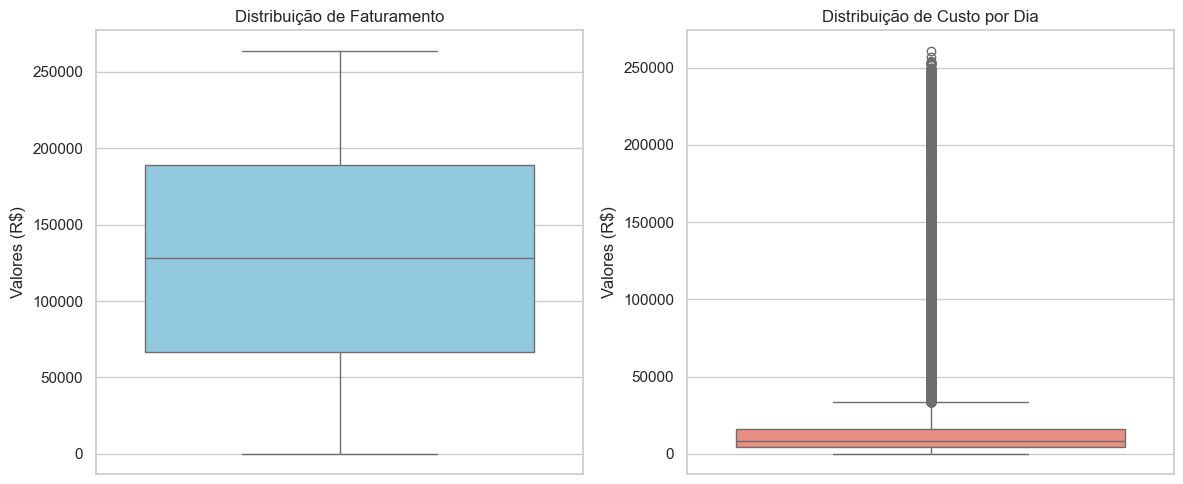

<Figure size 640x480 with 0 Axes>

In [23]:
# --- 5. Visualização dos Dados
# Nota Técnica: boxplot para análise de custos por internação 
# e por dia para análise de outliers

# Criação a área do gráfico para dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Boxplot para Faturamento
sns.boxplot(y=df_clean['billing_amount_br'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Faturamento')
axes[0].set_ylabel('Valores (R$)')

# --- Boxplot para Custo por Dia
sns.boxplot(y=df_clean['cost_per_day_br'], ax=axes[1], color='salmon')
axes[1].set_title('Distribuição de Custo por Dia')
axes[1].set_ylabel('Valores (R$)')

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.show()
plt.savefig('plots/7_custos_total_diario.png', dpi=300)

**`Análise da Feature: 'is_catastrophic_case' (Casos Catastróficos)`**

* **Distribuição de Faturamento:** comportamento simétrico, sem outliers.
* **Distribuição de Custo por Dia:** outliers diários com custos que superam 250 mil reais.

* **`Insight de Negócio:`** ter 11.17% da carteira (6.127 registros) classificada como caso catastrófico traz um alerta importante. Os casos representam internações curtas, nas quais o custo total foi dividido por poucos dias. Para o negócio, isso significa que o maior dreno financeiro diário da operadora vem de pacientes agudos de alta complexidade que entram, realizam procedimentos de alto custo e tem alta rápida.

* **`Insight de Negócio:`** modelo de auditoria concorrente é ideal para os casos catastróficos. Controlar o protocolo clínico nas primeiras 48 horas desses casos agudos é onde as empresas conseguirão mitigar o custo alto.

* **`Insight de Negócio:`** modelos de cobrança Fee-for-Service (pagamento por item utilizado/diária aberta) deixa a operadora mais vulnerável a picos inflacionários de insumos logo no início da internação. negociar com a rede credenciada modelos de Diárias Globais ou DRG (Diagnosis Related Groups) para procedimentos agudos previsíveis pode ser ótimo para eliminar picos de custos acima de 200 mil reais.

In [24]:
# === FEATURE ENGINEERING: INTERAÇÃO DIAGNÓTICO E MEDICAÇÃO ===

# --- 1. Criação da Feature 'condition_medication'
# Nota de Negócio: Interação combinada de diagnóstico e medicamentos pode indicar alto custo
# Nota Técnica: Feature de agrupamento para avaliar a interação Diagnóstico x Medicamento X Custo Diário
df_clean.loc[:, 'condition_medication'] = df_clean['medical_condition'] + '_' + df_clean['medication']

print("✅ Criação da Feature 'condition_medication' Concluída")
print('=' * 90)

print("\n📊 Análise de Longa Permanência e Custos por Condição/Medicamento:\n" + '=' * 90)

# --- 2. Agrupamento usando dicionário para especificar a métrica de cada coluna
df_analise = df_clean.groupby('condition_medication').agg(
    custo_diario_medio=('cost_per_day_br', 'mean'),           # custo diário médio
    total_pacientes=('is_long_stay', 'count'),                # total de pacientes
    casos_long_stay=('is_long_stay', 'sum'),                  # casos de longa permanência (>23 dias)
    taxa_proporcao=('is_long_stay', 'mean')                   # % de internação prolongada no referido grupo
).round(4)

# --- 3. Formatação visual da taxa em porcentagem
df_analise['taxa_proporcao'] = (df_analise['taxa_proporcao'] * 100).map('{:.2f}%'.format)

# --- 4. Formatação visual do custo em Real brasileiro (R$)
df_analise['custo_diario_medio'] = df_analise['custo_diario_medio'].map('R$ {:.2f}'.format)

# --- 5. Ordena pelos grupos que geram mais casos de internação longa
df_analise = df_analise.sort_values(by='custo_diario_medio', ascending=False)

display(df_analise)

✅ Criação da Feature 'condition_medication' Concluída

📊 Análise de Longa Permanência e Custos por Condição/Medicamento:


,custo_diario_medio,total_pacientes,casos_long_stay,taxa_proporcao
condition_medication,,,,
Arthritis_Ibuprofen,R$ 18434.19,1804,414,22.95%
Asthma_Penicillin,R$ 18238.37,1824,440,24.12%
Hypertension_Lipitor,R$ 18100.47,1818,412,22.66%
Obesity_Aspirin,R$ 18008.25,1848,403,21.81%
Hypertension_Ibuprofen,R$ 17960.43,1869,404,21.62%
Obesity_Ibuprofen,R$ 17932.45,1833,418,22.80%
Obesity_Penicillin,R$ 17796.49,1869,410,21.94%
Diabetes_Penicillin,R$ 17657.63,1859,442,23.78%
Diabetes_Paracetamol,R$ 17636.70,1791,426,23.79%


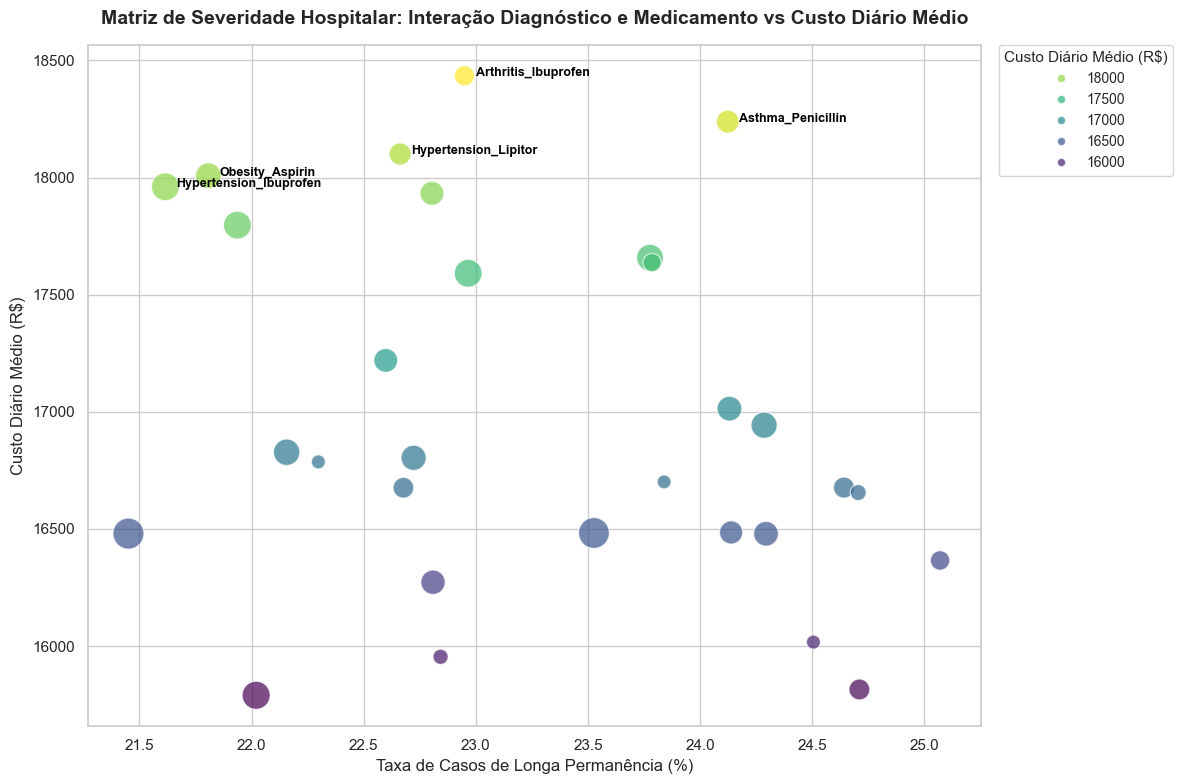

In [25]:
# --- 6. Visualização dos Dados

# --- Plot 1: Gráfio de Dispersão

# Configuração do estilo visual
sns.set_theme(style="whitegrid")

# Agrupamento, cálculo percentual e ordenação integrados em um único pipeline
df_plot_scatter = (
    df_clean.groupby('condition_medication')
    .agg(
        custo_diario_medio=('cost_per_day_br', 'mean'),
        total_pacientes=('is_long_stay', 'count'),
        taxa_proporcao=('is_long_stay', 'mean')
    )
    .assign(taxa_proporcao=lambda x: x['taxa_proporcao'] * 100)
    .sort_values(by='custo_diario_medio', ascending=False)
    .reset_index()
)

# Criação a área do gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Plot de dispersão (Bubble Chart)
sns.scatterplot(
    data=df_plot_scatter,
    x='taxa_proporcao',
    y='custo_diario_medio',
    size='total_pacientes',
    hue='custo_diario_medio',
    palette='viridis',
    sizes=(100, 500),
    alpha=0.7,
    ax=ax
)

# Anotações Estratégicas (Top 5 Grupos Mais Caros)
for _, row in df_plot_scatter.head(5).iterrows():
    ax.text(
        x=row['taxa_proporcao'] + 0.05,  # Pequeno deslocamento para evitar sobreposição
        y=row['custo_diario_medio'],
        s=row['condition_medication'],
        fontsize=9,
        fontweight='semibold',
        color='black'
    )

# Customização de rótulos e títulos executivos
ax.set_title('Matriz de Severidade Hospitalar: Interação Diagnóstico e Medicamento vs Custo Diário Médio', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Taxa de Casos de Longa Permanência (%)', fontsize=12)
ax.set_ylabel('Custo Diário Médio (R$)', fontsize=12)

# Ajuste e formatação da legenda
handles, labels = ax.get_legend_handles_labels()

# Captura os elementos de custo (posições 1 a 5) e inverte do maior para o menor
ax.legend(
    handles[5:0:-1], 
    labels[5:0:-1], 
    title="Custo Diário Médio (R$)", 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1),        
    borderaxespad=0,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.savefig('plots/8_matriz_severidade_diagnostico_medicao.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'condition_medication' (Interação Diagnóstico e Medicação vs Custo Diário Médio)`**

* A Matriz de Severidade Hospitalar permitiu isolar o risco combinado de diagnósticos e esquemas terapêuticos. Grupos como Arthritis_Ibuprofen e Asthma_Penicillin foram identificados como os principais focos de vulnerabilidade atuarial, liderando tanto o custo diário médio quanto a taxa de internações prolongadas (>23 dias). <br>
* O gráfico mapeia com precisão a severidade combinada, identificando **Grupos de Risco Cruzado**. Grupos no quadrante superior direito (como Arthritis_Ibuprofen e Asthma_Penicillin) representam o pior cenário probabilístico: possuem o maior custo diário médio e, simultaneamente, a maior taxa de conversão para longa permanência (>23 dias). <br>
* O total de pacientes (representado pela dimensão das bolhas) está distribuído de forma homogênea pelo gráfico, provando que os grupos com alta frequência de ocorrência (bolhas maiores) não são necessariamente os mais caros ou os que passam mais tempo internados. <br>

* **`Insight de Negócio:`** a combinação Asthma_Penicillin (Asma com Penicilina) ocupa zona de alto risco. Crises de asma severas que exigem antibioticoterapia prolongada indicam infecções respiratórias secundárias graves. A operadora de saúde pode criar um Programa de Gestão de Pacientes Asmáticos Crônicos, oferecendo acompanhamento ambulatorial preventivo e vacinação pneumocócica fora do hospital, a fim de evitar que esse paciente descompense e precise de internação, reduzindo os maiores picos de sinistralidade da carteira.


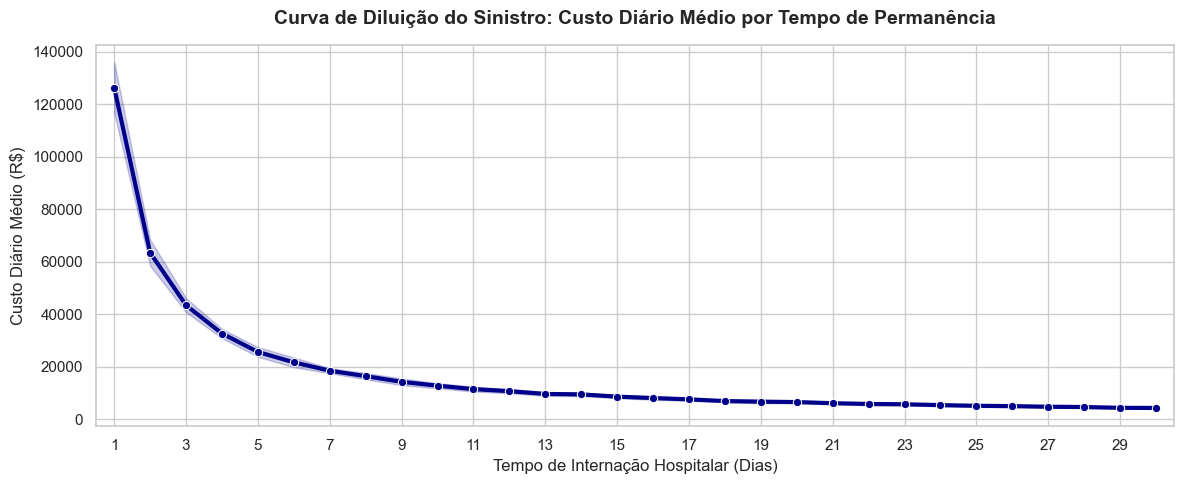

In [26]:
# --- Plot 2: Gráfio de Linha de Tendência Agregada

# Configuração do Estilo Visual
sns.set_theme(style="whitegrid")

# Agrupamendo apenas por tempo de internação para pegar o comportamento geral da carteira
df_tendencia = (
    df_clean.groupby(
        ['condition_medication', 'length_of_stay'])
    .agg(
        custo_diario_medio=('cost_per_day_br', 'mean'))
    .reset_index()
)

# Construção do Gráfico de Linha (Tendência de Diluição)
fig, ax = plt.subplots(figsize=(12, 5))

# O lineplot com estimador cria a linha média e a sombra do intervalo de variação
sns.lineplot(
    data=df_tendencia,
    x='length_of_stay',
    y='custo_diario_medio',
    color='darkblue',
    linewidth=3,
    marker='o',         # adiciona pontos na linha para marcar cada dia
    markersize=6,
    errorbar='sd',      # desenha uma sombra mostrando o desvio padrão (variação entre patologias)
    ax=ax
)

# Customização de títulos e rótulos para apresentação
ax.set_title('Curva de Diluição do Sinistro: Custo Diário Médio por Tempo de Permanência', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Tempo de Internação Hospitalar (Dias)', fontsize=12)
ax.set_ylabel('Custo Diário Médio (R$)', fontsize=12)

# Ajuste dos limites do eixo x
ax.set_xlim(0.5, 30.5)
ax.set_xticks(range(1, 31, 2)) # mostra os dias de 2 em 2

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/9_curva_tendencia_diluicao_sinistro.png', dpi=300, bbox_inches='tight')
plt.show()

**`Análise da Feature: 'condition_medication' (Interação Diagnóstico e Medicação vs Custo Diário Médio por Tempo de Permanência)`**

*  Gráfico comprova que a relação entre o tempo de internação (length_of_stay) e o custo diário médio (cost_per_day_br) segue uma função de decréscimo contínua. Ele começa com um pico agressivo no Dia 1, decai abruptamente até o 3 dia, e depois decai de forma suave até estabilizar por volta do 15º dia. <br>
* A faixa sombreada azul ao redor da linha representa a variação (desvio padrão) entre as diferentes patologias e medicações em cada dia específico. A sombra acompanha a linha de forma muito sutil e uniforme, indicando que, independentemente da doença e medicação, o fator que realmente dita o custo por dia nesta base é o denominador tempo, e não a patologia isolada.

* **`Nota Técnica:`** a partir do 23º dia (threshold definido para a feature 'is_long_stay' via percentil 75%), a curva perde inclinação e atinge um "plateau" estável de custo mínimo. Isso valida matematicamente que sua regra de corte de 23 dias separa com precisão o momento em que o paciente deixa de gerar variação financeira expressiva para a operadora e passa a ter um custo de manutenção linear.

* **`Insight de Negócio:`** no início da internação (dias 1 a 5), concentram-se os custos fixos mais altos do sinistro (por exemplo: taxas de sala cirúrgica, exames laboratoriais e de imagem urgentes, anestesistas e insumos de alta complexidade - OPME). À medida que os dias passam e o paciente entra em fase de recuperação e vigilância clínica, esses custos iniciais são divididos por um número maior de dias, e o custo da diária passa a refletir apenas a hotelaria hospitalar básica e cuidados gerais.

* **`Insight de Negócio:`** os primeiros dias concentram a volatilidade financeira e a agressividade dos custos, assim, concentrar os esforços de auditoria concorrente e protocolos de desospitalização preventiva (como a transição para Home Care) devem ser intensificados justamente na primeira semana de internação, onde há maior espaço para negociar pacotes de procedimentos e evitar desperdícios assistenciais antes que o custo diário seja diluído pelo tempo.

In [27]:
# === FEATURE ENGINEERING: MÊS DE ADMISSÃO (ANÁLISE DE SAZONALIDADE) ===

# --- 1. Análise do período analisado
print("✅ Análise do Período Analisado Concluída:\n" + '=' * 45)
print(f"* Data Mínima: {df_clean['date_of_admission'].min()}.")
print(f"* Data Máxima: {df_clean['date_of_admission'].max()}.")

✅ Análise do Período Analisado Concluída:
* Data Mínima: 2019-05-08 00:00:00.
* Data Máxima: 2024-05-07 00:00:00.


📊 Volume Acumulado de Internações por Mês (Período de 5 anos):
Mês 01 | Total de Admissões: 4646   | Média Anual Estimada: 774
Mês 02 | Total de Admissões: 4199   | Média Anual Estimada: 699
Mês 03 | Total de Admissões: 4610   | Média Anual Estimada: 768
Mês 04 | Total de Admissões: 4466   | Média Anual Estimada: 744
Mês 05 | Total de Admissões: 4547   | Média Anual Estimada: 757
Mês 06 | Total de Admissões: 4640   | Média Anual Estimada: 773
Mês 07 | Total de Admissões: 4762   | Média Anual Estimada: 793
Mês 08 | Total de Admissões: 4777   | Média Anual Estimada: 796
Mês 09 | Total de Admissões: 4503   | Média Anual Estimada: 750
Mês 10 | Total de Admissões: 4605   | Média Anual Estimada: 767
Mês 11 | Total de Admissões: 4501   | Média Anual Estimada: 750
Mês 12 | Total de Admissões: 4604   | Média Anual Estimada: 767


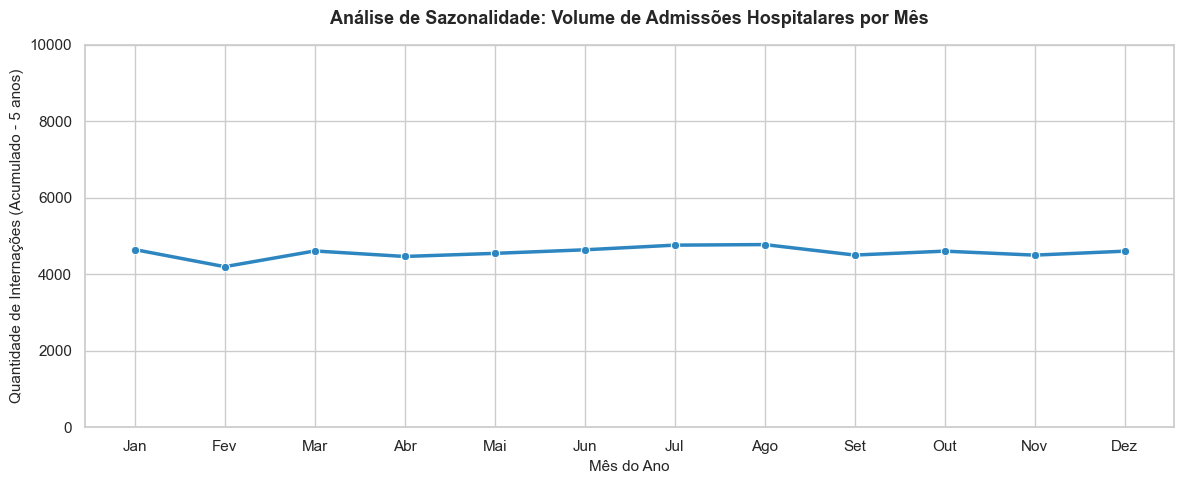

In [28]:
# --- 2. Extração do Mês e do Ano da data de admissão
df_clean.loc[:, 'admission_month'] = df_clean['date_of_admission'].dt.month

# --- 3. Agrupamento para contar o volume de internações por mês (Acumulado dos 5 anos)
sazonalidade = df_clean['admission_month'].value_counts().sort_index()

print("📊 Volume Acumulado de Internações por Mês (Período de 5 anos):")
print('=' * 70)
for mes, qtd in zip(sazonalidade.index, sazonalidade.values):
    print(f"Mês {mes:02d} | Total de Admissões: {qtd:<6} | Média Anual Estimada: {int(qtd/6)}")
print('=' * 70)

# Plot do Gráfico de Linha (Análise Temporal)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Plot da linha com marcadores nos pontos
sns.lineplot(x=sazonalidade.index, y=sazonalidade.values, marker='o', color='#2E86C1', linewidth=2.5, ax=ax)

# Customização de títulos e rótulos para apresentação
ax.set_title('Análise de Sazonalidade: Volume de Admissões Hospitalares por Mês', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Mês do Ano', fontsize=11)
ax.set_ylabel('Quantidade de Internações (Acumulado - 5 anos)', fontsize=11)
ax.set_ylim(0, 10000)

# Configurando o eixo X para exibir os nomes dos meses
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/10_sazonalidade_internacoes.png', dpi=300)

**`Análise da Feature: 'admission_month' (Mês de Admissão - Análise de Sazonalidade)`**

* **`Nota Técnica:`** a variável do mês de internação (month) não possui relevância estatística ou variabilidade real capaz de influenciar o custo, trata-se de ruído estatístico para o modelo.

* **`Insight de Negócio:`** não identificou-se picos sazonais que impliquem em sufoco financeiro em períodos específicos. O custo médio por internação é previsível e constante durante os 365 dias do ano, permitindo um planejamento orçamentário linear.



### Resumo Executivo: Etapa 1 - Análise Exploratória dos Dados

**1. LIMPEZA E TRATAMENTO DOS DADOS**


| Etapa / Iniciativa | Ação Aplicada | Impacto / Justificativa de Negócio | Métrica / Resultado |
| :--- | :--- | :--- | :--- |
| **Padronização de Nomenclatura** | 1. Conversão dos nomes das colunas (*lowercase + separação das palavras por underscore*); <br> 2. Conversão dos registros da coluna `name` para letras minúsculas (*lowercase*). | Elimina duplicidades ocultas geradas por inconsistências de digitação. | **100% das colunas** e nomes padronizados em caixa baixa. |
| **Tipagem de Variáveis** | Conversão de `date_of_admission` e `discharge_date` de tipo texto (*object*) para `datetime64[ns]`. | Permite a execução de cálculos matemáticos e lógicos utilizando eixos temporais. | Tipagem corrigida para **Datetime**. |
| **Ajuste Numérico** | Formatação do faturamento bruto (`billing_amount`) para duas casas decimais (`.2f`). | Alinhamento com o padrão financeiro de análise de custos médicos. | Valores normalizados em escala monetária. |
| **Tratamento de Duplicados** | Identificação e remoção de linhas 100% idênticas no banco de dados. | Eliminação de registros redundantes causados por possíveis falhas de integração ou reenvio de lotes de guias. | **534 linhas duplicadas removidas** (Base reduzida para 54.966 linhas). |
| **Consistência Temporal** | Validação da regra de negócio: Data de Alta $\ge$ Data de Admissão. | Garantia de integridade cronológica dos eventos assistenciais de saúde. | **0 inconsistências** detectadas. |
| **Tratamento de Anomalias (Valores Negativos)** | Exclusão de 106 registros com faturamento menor que zero (`billing_amount < 0`). | Eliminação de ruídos (glosas médicas totais ou erros de sistema) que distorceriam a modelagem de custo bruto do sinistro. | **106 linhas removidas** (0.19% da base). Base final: **54.860 linhas**. |


**2. ENGENHARIA DE FEATURES (*FEATURE ENGINEERING*)**

| Feature | Definição Estatística / Fórmula | Justificativa de Negócio | Impacto e Resultado de Negócio |
| :--- | :--- | :--- | :--- |
| **`length_of_stay`** | Subtração das datas de atendimento (`Alta - Admissão`). | Geração do indicador contínuo de **Tempo de Internação**, um dos principais vetores de custo hospitalar. | Variável gerada com **média de 15,5 dias** de permanência (Mín: 1 / Máx: 30). |
| **`billing_amount_br`** | Aplicação de taxa de câmbio média estável *(Fator: 5.00)*. | Alinhamento do **Target (Variável Alvo)** com a realidade financeira do mercado de saúde suplementar brasileiro. | Escala convertida para Real brasileiro, com **faturamento médio de R$ 127.973,17** por internação. |
| **`cost_per_day_br`** | Divisão do faturamento bruto em Reais pelo tempo de permanência (`billing_amount_br / length_of_stay`). | Normalização de custos, permitindo diferenciar procedimentos cirúrgicos rápidos/caros de internações clínicas longas. | **Custo diário médio de R$ 16.995,66** (Mediana: R$ 8.264,67). Presença de forte assimetria à direita (*cauda longa*) atingindo teto de R$ 261.059,25/dia. |
| **`age_group`** | Agrupamento etário em 10 intervalos regulatórios com base na RN nº 563 da ANS. | Mapeamento demográfico para capturar variações de risco assistencial por ciclo de vida, um dos fatores mais críticos na precificação e predição de sinistros | **Concentração massiva acima de 59 anos (39,56%)**. Custos e permanência mantiveram-se homogêneos entre as faixas etárias. <br><br> *`Insight:`* Risco demográfico elevado na carteira. <br><br> *`Modelagem:`* provavelmente terá baixa relevância (*feature importance*) por falta de quebra de variância. |
| **`is_weekend_admission`** | Identificação de internações ocorridas aos sábados e domingos, mapeadas a partir da data de admissão. | Avaliação do impacto da sazonalidade semanal (plantões e restrições operacionais de exames) na flutuação de custos. | Não apresentou variação estatística (custo estável em **~R$ 16.900,00/dia** na semana e no fim de semana).<br><br> *`Modelagem:`* **Feature Descontinuada** do pipeline final por parcimônia e ausência de ganho de informação (*Information Gain*). |
| **`is_long_stay`** | Flag binária para internações acima do terceiro quartil ($> 23$ dias). | Segmentação estratégica entre o comportamento de sinistros agudos e internações de longa permanência. | *`Modelagem:`* Forte poder de separação: o grupo de curta permanência retém a severidade diária (**R$ 20.706,34/dia**), enquanto o de longa internação cai para **R$ 4.747,77/dia** (Efeito Diluição). |
| **`condition_medication`** | Combinação categórica de Diagnóstico Clínico + Protocolo Farmacológico. | Mapeamento da complexidade do sinistro com base no cruzamento da patologia com o tratamento aplicado. | Consolidação de 30 combinações únicas. Custos totais mantiveram-se planos em **~R$ 128.000,00**.<br><br> *`Insight:`* Sugere tabelas de faturamento hospitalar engessadas ("pacotes fixos"), demandando auditoria médica concorrente. |
| **`is_catastrophic_case`** | Flag binária para custos diários superiores ao limite estatístico de outliers ($> R\$ 33.702,51$). | Isolamento e monitoramento de sinistros catastróficos para estratégias de contenção de risco de cauda (*tail risk*). | Identificou **6.127 casos (11,17% da carteira)**.<br><br> *`Modelagem:`* Entrega um sinal booleano limpo e de alta relevância preditiva para guiar os algoritmos no reconhecimento de picos de custo. |
| **`admission_month`** | Extração do mês de admissão para avaliar ciclos sazonais ao longo de 5 anos (período presente do dataset). | Identificação de picos sazonais de frequência (como surtos de inverno) para provisionamento de caixa e auditoria temporária. | Distribuição uniforme estável entre meses.<br><br> *`Modelagem:`* **Feature Descontinuada** devido à variação insignificante, caracterizando ruído de dados. |

In [29]:
### === Planejamento Estratégico de Modelagem (Regressão) ===

display(Markdown("### **3. PLANEJAMENTO ESTRATÉGICO DE MODELAGEM (*REGRESSÃO*)**"))

# --- 1. Definição Estratégica da Target
definicao_target = {
    'Definição da Target': [
        'Escolhida: cost_per_day_br', 
        'Descartada: billing_amount_br'
        ],
    'Justificativa': [
        'A normalização pelo tempo permite isolar a real severidade diária da internação, capturando os picos inflacionários causados por eventos agudos de alta complexidade',
        'Descartada pois o faturamento bruto uniforme amortece o sinal analítico, ocultando a volatilidade e o risco de cauda no decorrer dos dias'
    ]
}
display(Markdown("### === Definição Estratégica da Variável Alvo (Target) ==="))
display(pd.DataFrame(definicao_target))
display(Markdown("\n---\n"))

# --- 2. Definição das Estratégias de Pipeline
estrategia = {
    'Pipeline': ['01', '02', '03', '04', '05', '06', '07', '08'],
    'Modelo': [
        'Linear Regression', 
        'K-Neighbors Regressor (KNN)', 
        'Linear Support Vector Regressor (LinearSVR)', 
        'Multilayer Perceptron (MLP Neural Network)',
        'Random Forest Regressor', 
        'LightGBM Regressor', 
        'CatBoost Regressor', 
        'XGBoost Regressor'
    ],
    'Objetivo': [
        'Baseline Estatístico de Machine Learning', 
        'Abordagem Baseada em Distância e Vizinhança', 
        'Otimização de Hiperplano de Margem Máxima', 
        'Rede Neural Artificial para Captura de Padrões Complexos',
        'Ensemble de Árvores (Bagging) / Não-Linearidade', 
        'Alta Performance Computacional (Boosting)', 
        'Performance Otimizada para Variáveis Categóricas', 
        'Alta Performance Geral (Extreme Gradient Boosting)'
    ],
    'Pré-Processamento Obrigatório': [
        'Target Encoding + One-Hot Encoding + Standard Scaling',
        'Target Encoding + One-Hot Encoding + Standard Scaling',
        'Target Encoding + One-Hot Encoding + Standard Scaling',
        'Target Encoding + One-Hot Encoding + Standard Scaling',
        'Target Encoding + One-Hot Encoding',
        'Categorical Feature Handling Nativo',
        'Categorical Feature Handling Nativo',
        'Target Encoding'
    ],
    'Exige Escalonamento (Scaling)?': ['Sim', 'Sim', 'Sim', 'Sim', 'Não', 'Não', 'Não', 'Não'],
}
display(Markdown("### === Arquitetura do Pipeline de Modelagem (Regressão) ==="))
display(pd.DataFrame(estrategia))
display(Markdown("\n---\n"))


# --- 3. Estratégia de Métricas para Avaliação da Performance dos Modelos
metricas = {
    'Tipo de Métrica': [
        'Estatística (Eixo Clínico)', 
        'Estatística (Eixo de Risco)', 
        'Estatística (Aderência)', 
        'Negócio / Atuarial', 
        'Negócio / Monitoramento'
    ],
    'Métrica / Indicador': [
        'MAE (Mean Absolute Error)', 
        'RMSE (Root Mean Squared Error)', 
        'R² (Coefficient of Determination)',
        'Erro de Provisionamento Global (%)',
        'Taxa de Captura de Casos Catastróficos'
    ],
    'Definição Estatística / Cálculo': [
        'Média da soma dos erros absolutos entre os valores reais e preditos.',
        'Raiz quadrada da média dos erros elevados ao quadrado (penaliza erros grandes).',
        'Percentual da variação dos custos reais que é explicada pelas variáveis do modelo.',
        '((Soma de todos os custos preditos / Soma de todos os custos reais) - 1) * 100',
        'Percentual de acerto do modelo considerando apenas a subpopulação de diárias > R$ 33.702,51.'
    ],
    'Objetivo / Interpretação de Negócio': [
        'Avaliar o erro médio do modelo diretamente em Reais por diária (fácil leitura executiva).',
        'Penalizar severamente grandes desvios de previsão, sinalizando falhas nos custos mais severos.',
        'Mensurar o percentual de variabilidade do custo diário hospitalar que o modelo consegue explicar.',
        'Garantir a saúde do caixa medindo o viés acumulado do modelo (identifica subprovisionamento ou capital imobilizado).',
        'Mensurar o percentual de acerto do regressor especificamente na faixa de maior risco da carteira (proteção de cauda).'
    ]
}
display(Markdown("### === Matriz de Avaliação e Métricas Estatísticas ==="))
display(pd.DataFrame(metricas))

### **3. PLANEJAMENTO ESTRATÉGICO DE MODELAGEM (*REGRESSÃO*)**

### === Definição Estratégica da Variável Alvo (Target) ===

,Definição da Target,Justificativa
0,Escolhida: cost_per_day_br,"A normalização pelo tempo permite isolar a real severidade diária da internação, capturando os picos inflacionários causados por eventos agudos de alta complexidade"
1,Descartada: billing_amount_br,"Descartada pois o faturamento bruto uniforme amortece o sinal analítico, ocultando a volatilidade e o risco de cauda no decorrer dos dias"



---


### === Arquitetura do Pipeline de Modelagem (Regressão) ===

,Pipeline,Modelo,Objetivo,Pré-Processamento Obrigatório,Exige Escalonamento (Scaling)?
0,01,Linear Regression,Baseline Estatístico de Machine Learning,Target Encoding + One-Hot Encoding + Standard Scaling,Sim
1,02,K-Neighbors Regressor (KNN),Abordagem Baseada em Distância e Vizinhança,Target Encoding + One-Hot Encoding + Standard Scaling,Sim
2,03,Linear Support Vector Regressor (LinearSVR),Otimização de Hiperplano de Margem Máxima,Target Encoding + One-Hot Encoding + Standard Scaling,Sim
3,04,Multilayer Perceptron (MLP Neural Network),Rede Neural Artificial para Captura de Padrões Complexos,Target Encoding + One-Hot Encoding + Standard Scaling,Sim
4,05,Random Forest Regressor,Ensemble de Árvores (Bagging) / Não-Linearidade,Target Encoding + One-Hot Encoding,Não
5,06,LightGBM Regressor,Alta Performance Computacional (Boosting),Categorical Feature Handling Nativo,Não
6,07,CatBoost Regressor,Performance Otimizada para Variáveis Categóricas,Categorical Feature Handling Nativo,Não
7,08,XGBoost Regressor,Alta Performance Geral (Extreme Gradient Boosting),Target Encoding,Não



---


### === Matriz de Avaliação e Métricas Estatísticas ===

,Tipo de Métrica,Métrica / Indicador,Definição Estatística / Cálculo,Objetivo / Interpretação de Negócio
0,Estatística (Eixo Clínico),MAE (Mean Absolute Error),Média da soma dos erros absolutos entre os valores reais e preditos.,Avaliar o erro médio do modelo diretamente em Reais por diária (fácil leitura executiva).
1,Estatística (Eixo de Risco),RMSE (Root Mean Squared Error),Raiz quadrada da média dos erros elevados ao quadrado (penaliza erros grandes).,"Penalizar severamente grandes desvios de previsão, sinalizando falhas nos custos mais severos."
2,Estatística (Aderência),R² (Coefficient of Determination),Percentual da variação dos custos reais que é explicada pelas variáveis do modelo.,Mensurar o percentual de variabilidade do custo diário hospitalar que o modelo consegue explicar.
3,Negócio / Atuarial,Erro de Provisionamento Global (%),((Soma de todos os custos preditos / Soma de todos os custos reais) - 1) * 100,Garantir a saúde do caixa medindo o viés acumulado do modelo (identifica subprovisionamento ou capital imobilizado).
4,Negócio / Monitoramento,Taxa de Captura de Casos Catastróficos,"Percentual de acerto do modelo considerando apenas a subpopulação de diárias > R$ 33.702,51.",Mensurar o percentual de acerto do regressor especificamente na faixa de maior risco da carteira (proteção de cauda).


## **Etapa 2: Análise das Features para Modelagem**

In [62]:
# importar as bibliotecas

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import OneHotEncoder

In [31]:
# conferência e cópia do dataset para preparar para modelagem
df_model = df_clean.copy()

print(df_model.columns)

print('=' * 50)
print("✅ Cópia de Segurança para Modelagem Concluída\n" + '=' * 50)
print(f"Colunas: {df_model.shape[0]}")
print(f"Linhas: {df_model.shape[1]}")

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results', 'length_of_stay', 'billing_amount_br',
       'cost_per_day_br', 'age_group', 'is_weekend_admission', 'is_long_stay',
       'is_catastrophic_case', 'condition_medication', 'admission_month'],
      dtype='object')
✅ Cópia de Segurança para Modelagem Concluída
Colunas: 54860
Linhas: 24


### Seleção das Features para Modelagem

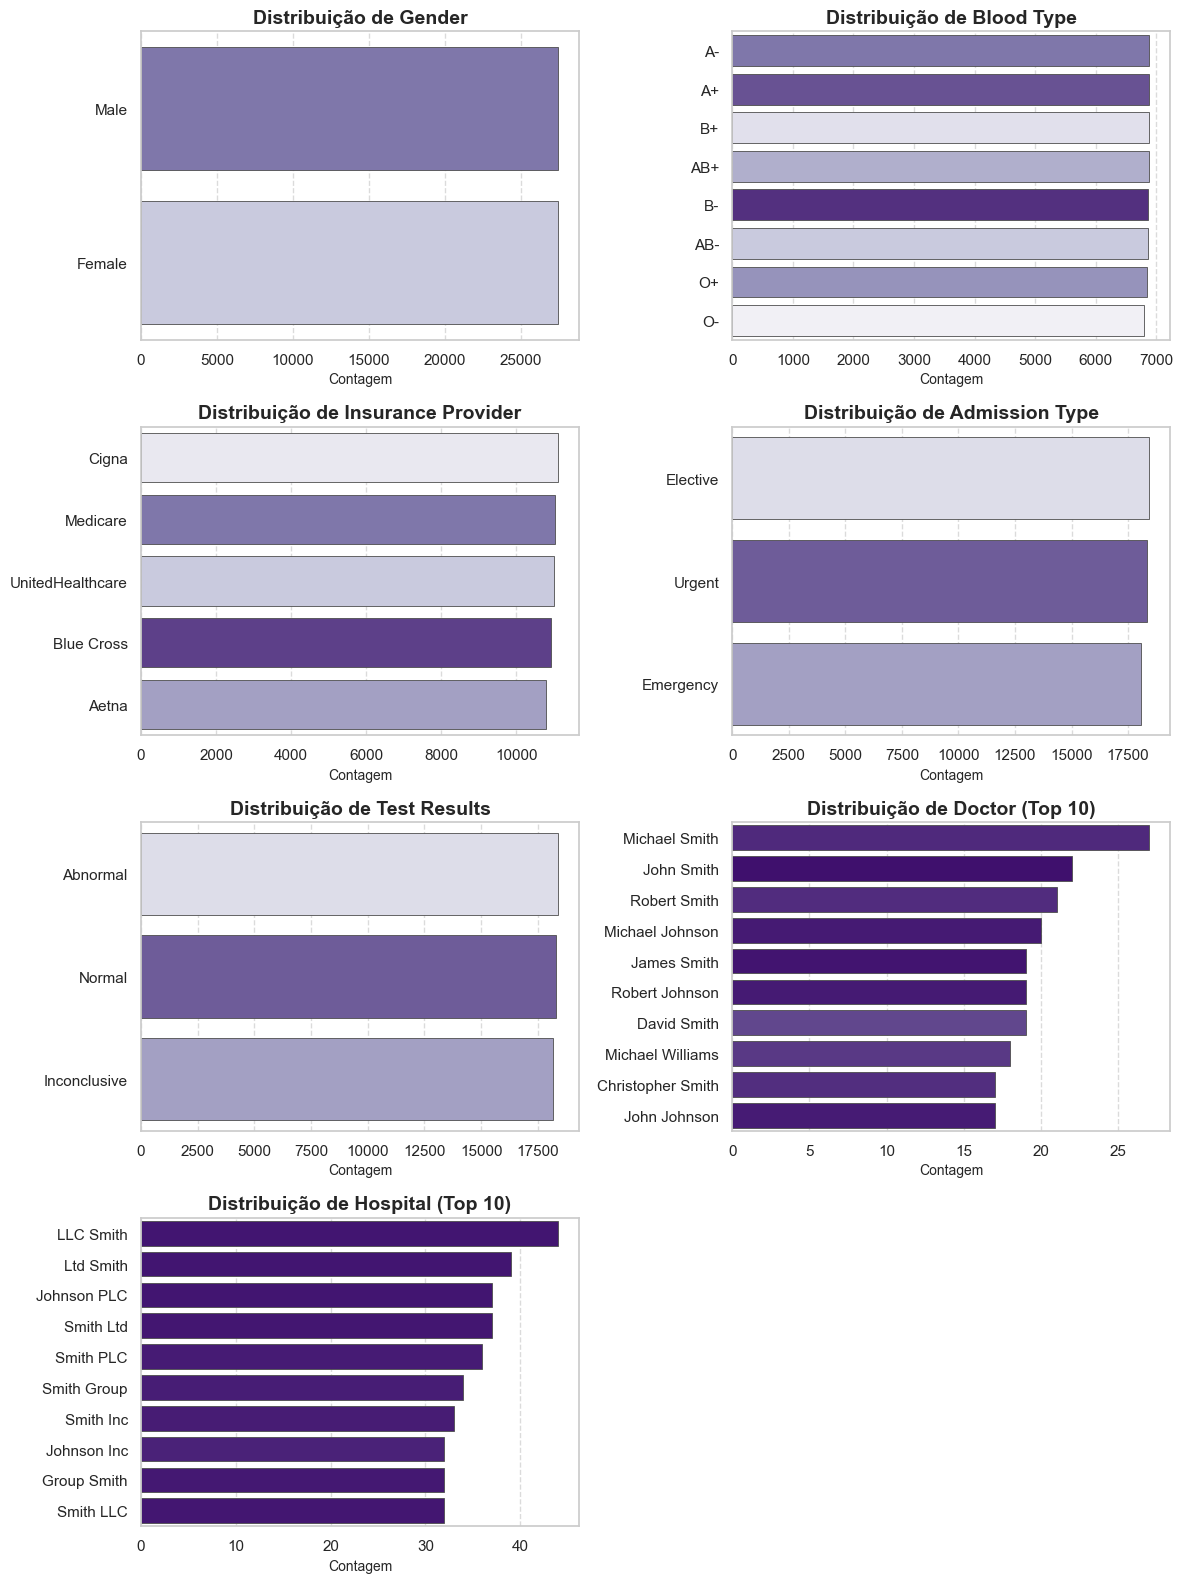

In [46]:
# === ANÁLISE DE DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS ===

# Lista das variáveis para análise
distribuicao_features = [
    "gender",
    "blood_type",
    "insurance_provider",
    "admission_type",
    "test_results",
    "doctor",
    "hospital"
]

# Configura o estilo dos gráficos
sns.set_theme(style="whitegrid")

# Criação da figura com 4 linhas e 2 colunas para plotagem
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))

# Achata a matriz de eixos para facilitar o loop (de 2D para 1D)
axes = axes.flatten()

# Loop para plotar cada variável
for i, feature in enumerate(distribuicao_features):
    # Conta a frequência e ordena as barras da maior para a menor
    order = df_model[feature].value_counts().index

    # Se a variável tiver muitos valores únicos,
    # mostra apenas os 10 mais frequentes
    if df_model[feature].nunique() > 10:
        order = order[:10]
        title_suffix = " (Top 10)"
    else:
        title_suffix = ""

    sns.countplot(
        data=df_model,
        y=feature,
        ax=axes[i],
        order=order,
        palette="Purples_r",
        hue=feature,
        legend=False,
        edgecolor="0.3",    # borda sutil para separar os tons de roxo
        linewidth=0.6
    )

    axes[i].set_title(
        f"Distribuição de {feature.replace('_', ' ').title()}{title_suffix}",
        fontsize=14,
        weight="bold",
    )
    axes[i].set_xlabel("Contagem", fontsize=10)
    axes[i].set_ylabel("")

    # Remove as linhas de grade verticais para o visual ficar mais minimalista
    axes[i].xaxis.grid(True, linestyle="--", alpha=0.7)
    axes[i].yaxis.grid(False)

# Ajuste para manter o último subplot vazio (7 plots para 8 espaços)
axes[-1].axis("off")

# Ajustes finais de layout e salvamento
plt.tight_layout()
plt.savefig('plots/11_distribuicao_features_cat.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# === Avaliação de Impacto e Distribuição das Variáveis Categóricas ===

# Análise Estatística: p_value
# Para respaldar estatisticamente o descarte das variáveis categóricas

print("========= ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES =========\n")

features_para_descartar = []
features_para_manter = []

# Avaliação Estatística das Features para Manter ou Descartar da Modelagem
for col in distribuicao_features:
    if col in df_model.columns:
        print("=" * 90)
        print(f"📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: {col} | Cardinalidade: {df_model[col].nunique()} categorias")
        print("=" * 90)
        
        # 1. Distribuição de Frequência (Para checar a simetria/uniformidade)
        frequencia = df_model[col].value_counts()
        proporcao = df_model[col].value_counts(normalize=True) * 100
        df_dist = pd.DataFrame({'Contagem': frequencia, 'Proporção (%)': proporcao.round(2)})
        
        if df_model[col].nunique() > 10:
            print("▶ Distribuição (Apenas as 5 primeiras categorias devido à alta cardinalidade):")
            print(df_dist.head(5))
            print(f"... e outras {df_model[col].nunique() - 5} categorias.")
        else:
            print("▶ Distribuição de Frequência Completa:")
            print(df_dist)
            
        # 2. Impacto na Variável Alvo (cost_per_day_br)
        if 'cost_per_day_br' in df_model.columns:
            print("\n▶ Resumo Estatístico do Target por Categoria:")
            resumo_target = df_model.groupby(col)['cost_per_day_br'].agg(['count', 'mean', 'median', 'std']).round(2)
            
            if df_model[col].nunique() > 10:
                print(resumo_target.head(5))
            else:
                print(resumo_target)
            
            # 3. Teste Estatístico (ANOVA) para validar se as diferenças são reais ou flutuação aleatória
            grupos = [grupo['cost_per_day_br'].values for nome, grupo in df_model.groupby(col)]
            
            if len(grupos) > 1:
                try:
                    f_stat, p_val = stats.f_oneway(*grupos)
                    print(f"\n▶ Teste ANOVA: F-Statistic = {f_stat:.4f} | p-value = {p_val:.4e}")
                    
                    if p_val > 0.05:
                        print(f"❌ CONCLUSÃO: p-value > 0.05 ({p_val:.4f}). O custo diário NÃO varia entre as categorias.")
                        print(f"   A variável '{col}' provavelmente é ruído sintético uniforme. Recomendado DESCARTE.")
                        features_para_descartar.append(col)
                    else:
                        print(f"✅ CONCLUSÃO: p-value <= 0.05 ({p_val:.4e}). Existe variação significativa no custo entre as categorias.")
                        print(f"   A variável '{col}' possui sinal preditivo útil. Manter na MODELAGEM.")
                        features_para_manter.append(col)
                except Exception as e:
                    print(f"⚠️ Não foi possível rodar o teste estatístico: {e}")
        print("\n")

print("=" * 60)
print("📋 RESUMO: ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES")
print("=" * 60)
print(f"❌ Sugestão de DESCARTE (Apenas Ruído Simétrico): {features_para_descartar}")
print(f"✅ Sugestão de MANUTENÇÃO (Possuem Padrão/Sinal): {features_para_manter}")


========= ANÁLISE DE DISTRIBUIÇÃO E SELEÇÃO DE FEATURES =========

📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: gender | Cardinalidade: 2 categorias
▶ Distribuição de Frequência Completa:
        Contagem  Proporção (%)
gender                         
Male       27449          50.03
Female     27411          49.97

▶ Resumo Estatístico do Target por Categoria:
        count      mean   median       std
gender                                    
Female  27411  16949.51  8279.53  28945.13
Male    27449  17041.76  8239.95  29069.45

▶ Teste ANOVA: F-Statistic = 0.1387 | p-value = 7.0957e-01
❌ CONCLUSÃO: p-value > 0.05 (0.7096). O custo diário NÃO varia entre as categorias.
   A variável 'gender' provavelmente é ruído sintético uniforme. Recomendado DESCARTE.


📈 ANÁLISE ESTATÍSTICA DA VARIÁVEL: blood_type | Cardinalidade: 8 categorias
▶ Distribuição de Frequência Completa:
            Contagem  Proporção (%)
blood_type                         
A-              6882          12.54
A+              687

In [43]:
# === TARGET ENCODING BASEADO EM RISCO/CUSTO PARA VARIÁVEL HOSPITAIS ===

print("=== Agrupamento de Hospitais por Quartis de Custo Médio ===")

# 1. Calcular a média de custo e a volumetria de cada hospital
stats_hospital = (
    df_model.groupby("hospital")["cost_per_day_br"]
    .agg(["mean", "count"])
    .reset_index()
)

# 2. Separar apenas os hospitais com volume confiável para calcular os quartis reais
# (Hospitais que aparecem pelo menos 3 vezes no dataset)
hospitais_confiaveis = stats_hospital[stats_hospital["count"] >= 3]

# 3. Calcular os quartis baseados nas médias desses hospitais representativos
Q1 = hospitais_confiaveis["mean"].quantile(0.25)
Q2 = hospitais_confiaveis["mean"].quantile(0.50)  # mediana
Q3 = hospitais_confiaveis["mean"].quantile(0.75)

print(f"◆ Limiar Baixo Custo (Q1): até R$ {Q1:,.2f}")
print(f"◆ Limiar Custo Padrão (Q2): Mediana em R$ {Q2:,.2f}")
print(f"◆ Limiar Alto Custo  (Q3): acima de R$ {Q3:,.2f}\n")

# 4. Criação da função que aplica a regra de negócio baseada em Quartis
def classificar_por_quartil(row):
    # Proteção: Se o hospital tiver pouquíssimos registros, será alocado em Padrão (Evita Overfitting)
    if row["count"] < 3:
        return "hospital_custo_padrao"

    # Regra de Negócio Aplicada:
    if row["mean"] <= Q1:
        return "hospital_baixo_custo"
    elif row["mean"] > Q3:
        return "hospital_alto_custo"
    else:
        return "hospital_custo_padrao"  # fica entre Q1 e Q3 (Engloba Q2)


# 5. Aplicar a classificação no resumo dos hospitais
stats_hospital["hospital_cluster"] = stats_hospital.apply(
    classificar_por_quartil, axis=1
)

# 6. Mapear as novas categorias de volta para o DataFrame de modelagem original
mapa_hospitais = dict(
    zip(stats_hospital["hospital"],
        stats_hospital["hospital_cluster"]
        )
)
df_model["hospital_cluster"] = df_model["hospital"].map(mapa_hospitais) # aplica o dict ao df_model

# Exibe como ficou a nova distribuição no seu dataset
print("■ Nova distribuição da coluna transformada:")
print(df_model["hospital_cluster"].value_counts(normalize=True) * 100)

=== Agrupamento de Hospitais por Quartis de Custo Médio ===
◆ Limiar Baixo Custo (Q1): até R$ 7,565.98
◆ Limiar Custo Padrão (Q2): Mediana em R$ 11,651.96
◆ Limiar Alto Custo  (Q3): acima de R$ 19,994.60

■ Nova distribuição da coluna transformada:
hospital_cluster
hospital_custo_padrao    89.901568
hospital_alto_custo       5.905942
hospital_baixo_custo      4.192490
Name: proportion, dtype: float64


**`Análise das Features Categóricas:`**

* Dentre as features avaliadas via teste estatístico ANOVA, apenas 'doctor' e 'hospital' apresentaram relevância e variação significativa sobre a variável alvo (cost_per_day_br). <br>
* A variável 'doctor' possui altíssima cardinalidade (40.276 categorias) com comportamento esparso: a categoria de maior frequência possui apenas 27 registros (representando 0,05% do dataset). Devido a essa pulverização extrema, a variável não trará ganho de generalização para o modelo e será descartada. <br> 

**`Regra de Negócio (Feature Engineering): 'hospital_cluster'`** <br>
*  A variável 'hospital' também apresenta alta cardinalidade (39.815 categorias), mas retém um sinal preditivo valioso devido a fortes discrepâncias de custo médio entre os estabelecimentos. <br>
* Para viabilizar a modelagem sem explodir a dimensionalidade, aplicou-se uma técnica de agrupamento baseada em quartis de custo e volumetria, consolidando-a em 3 categorias limpas: <br>
- hospital_alto_custo: Hospitais com custo médio acima do terceiro quartil ($Q3$). <br>
- hospital_baixo_custo: Hospitais com custo médio abaixo do primeiro quartil ($Q1$). <br>
- hospital_custo_padrao: Hospitais com custo médio central (entre $Q1$ e $Q3$) ou estabelecimentos com baixa amostragem no dataset (menos de 3 aparições), mitigando o risco de overfitting. <br>

Como você bem escreveu no seu comentário: "(usando apenas dados passados)... mapear isso no conjunto de treino e dar merge no teste".Se você rodar o agrupamento direto no df_clean (antes de separar o treino do teste), uma pequena quantidade de informação do seu conjunto de teste vai vazar para o cálculo da mediana. Para garantir que seu código seja 100% à prova de balas para uma auditoria ou publicação, a ordem dos fatores deve ser exatamente esta:Separar o seu dataset em Treino ($70\%$) e Teste ($30\%$).Calcular o dicionário mediana_por_condicao apenas olhando para os dados de Treino.Aplicar o .map() tanto no Treino quanto no Teste usando esse dicionário gerado pelo treino.

In [65]:
## ULTIMA VERSÃO


def pipeline_master_modelagem(
    df, target_col="cost_per_day_br", test_size=0.3, random_state=42
):
    """Pipeline master que blinda contra Data Leakage, executa engenharia

    de proxies temporários e bifurca os dados com logs de confirmação.
    """
    print("\n" + "=" * 80)
    print(" ▶ INICIANDO PIPELINE MASTER DE PROCESSAMENTO DE DADOS")
    print("=" * 80)

    # 1. Separação de Features de Interesse e Target
    features_necessarias = [
        "age",
        "hospital_cluster",
        "medical_condition",
        "length_of_stay",
    ]
    X = df[features_necessarias].copy()
    y = df[target_col].copy()

    # 2. Divisão Estrita entre Treino e Teste (Garantia anti-leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print("✔ [CONFIRMAÇÃO] Divisão dos dados realizada com sucesso!")
    print(
        f"   ➔ Volumetria Treino: {X_train.shape[0]} linhas | Volumetria Teste: {X_test.shape[0]} linhas"
    )
    print("-" * 80)

    # 3. Engenharia de Features (Proxies de Tempo de Internação baseados no Treino)
    print("▶ Executando Feature Engineering (Criação de Proxies Históricos)...")
    mediana_por_condicao = (
        X_train.groupby("medical_condition")["length_of_stay"].median().to_dict()
    )
    mediana_global_treino = X_train["length_of_stay"].median()

    # Aplicando proxies no Treino e Teste
    for dataset in [X_train, X_test]:
        dataset["expected_length_of_stay"] = dataset["medical_condition"].map(
            mediana_por_condicao
        )
        dataset["expected_length_of_stay"] = dataset[
            "expected_length_of_stay"
        ].fillna(mediana_global_treino)
        dataset["expected_is_long_stay"] = (
            dataset["expected_length_of_stay"] > 23
        ).astype(int)

    # Limpeza de colunas brutas/temporais futuras
    features_finais_base = [
        "age",
        "hospital_cluster",
        "expected_length_of_stay",
        "expected_is_long_stay",
    ]
    X_train = X_train[features_finais_base]
    X_test = X_test[features_finais_base]

    print(
        "✔ [CONFIRMAÇÃO] Engenharia de Recursos concluída sem vazamento de dados."
    )
    print(
        f"   ➔ Features temporárias geradas: 'expected_length_of_stay' e 'expected_is_long_stay'"
    )
    print("-" * 80)

    # =========================================================================
    # ESTRUTURA 1: DADOS PARA LIGHTGBM / CATBOOST (Categorias Nativas)
    # =========================================================================
    print(
        "▶ Estruturando dados para algoritmos de Boosting (Categorias Nativas)..."
    )

    X_train_native = X_train.copy()
    X_test_native = X_test.copy()

    X_train_native["hospital_cluster"] = X_train_native[
        "hospital_cluster"
    ].astype("category")
    X_test_native["hospital_cluster"] = X_test_native[
        "hospital_cluster"
    ].astype("category")

    print(
        "✔ [CONFIRMAÇÃO] One-Hot Encoding NÃO aplicado para este conjunto."
    )
    print(
        "   ➔ Coluna 'hospital_cluster' mapeada estritamente como tipo 'category'."
    )
    print(
        "   🎯 DESTINO OBRIGATÓRIO: Destinado aos pipelines [06] LightGBM e [07] CatBoost."
    )
    print("-" * 80)

    # =========================================================================
    # ESTRUTURA 2: DADOS PARA LINEARES / KNN / SVR / MLP / RANDOM FOREST
    # =========================================================================
    print(
        "▶ Aplicando One-Hot Encoding no 'hospital_cluster' para modelos tradicionais..."
    )

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    ohe_train = ohe.fit_transform(X_train[["hospital_cluster"]])
    ohe_test = ohe.transform(X_test[["hospital_cluster"]])

    colunas_dummy = [f"cluster_{cat}" for cat in ohe.categories_[0]]
    df_ohe_train = pd.DataFrame(
        ohe_train, columns=colunas_dummy, index=X_train.index
    )
    df_ohe_test = pd.DataFrame(
        ohe_test, columns=colunas_dummy, index=X_test.index
    )

    X_train_encoded = pd.concat(
        [X_train.drop(columns=["hospital_cluster"]), df_ohe_train], axis=1
    )
    X_test_encoded = pd.concat(
        [X_test.drop(columns=["hospital_cluster"]), df_ohe_test], axis=1
    )

    print("✔ [CONFIRMAÇÃO] One-Hot Encoding aplicado com sucesso!")
    print(f"   ➔ Novas colunas dummificadas: {colunas_dummy}")
    print(
        "   🎯 DESTINO OBRIGATÓRIO: Destinado aos pipelines [01] Linear Regression, [02] KNN,"
    )
    print(
        "                          [03] LinearSVR, [04] MLP e [05] Random Forest."
    )

    print("=" * 80)
    print(" 🏁 PIPELINE CONCLUÍDA! ESTRUTURAS DE DADOS PRONTAS PARA O TREINO")
    print("=" * 80 + "\n")

    return (
        X_train_encoded,
        X_test_encoded,
        X_train_native,
        X_test_native,
        y_train,
        y_test,
    )


# --- Para executar no seu código principal ---
X_train_enc, X_test_enc, X_train_nat, X_test_nat, y_train, y_test = pipeline_master_modelagem(df_model)


 ▶ INICIANDO PIPELINE MASTER DE PROCESSAMENTO DE DADOS
✔ [CONFIRMAÇÃO] Divisão dos dados realizada com sucesso!
   ➔ Volumetria Treino: 38402 linhas | Volumetria Teste: 16458 linhas
--------------------------------------------------------------------------------
▶ Executando Feature Engineering (Criação de Proxies Históricos)...
✔ [CONFIRMAÇÃO] Engenharia de Recursos concluída sem vazamento de dados.
   ➔ Features temporárias geradas: 'expected_length_of_stay' e 'expected_is_long_stay'
--------------------------------------------------------------------------------
▶ Estruturando dados para algoritmos de Boosting (Categorias Nativas)...
✔ [CONFIRMAÇÃO] One-Hot Encoding NÃO aplicado para este conjunto.
   ➔ Coluna 'hospital_cluster' mapeada estritamente como tipo 'category'.
   🎯 DESTINO OBRIGATÓRIO: Destinado aos pipelines [06] LightGBM e [07] CatBoost.
--------------------------------------------------------------------------------
▶ Aplicando One-Hot Encoding no 'hospital_cluster' p

In [63]:
def pipeline_master_modelagem(
    df, target_col="cost_per_day_br", test_size=0.3, random_state=42
):
    """Pipeline que blinda contra Data Leakage e bifurca os dados em duas

    estruturas: uma com One-Hot Encoding e outra com Categorias Nativas para
    Boostings.
    """
    print(" ─── Iniciando Pipeline Master de Dados ───")

    # 1. Separação de Features de Interesse e Target
    features_necessarias = [
        "age",
        "hospital_cluster",
        "medical_condition",
        "length_of_stay",
    ]
    X = df[features_necessarias].copy()
    y = df[target_col].copy()

    # 2. Divisão Estrita entre Treino e Teste (Garantia anti-leakage)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 3. Engenharia de Features (Proxies de Tempo de Internação baseados no Treino)
    mediana_por_condicao = (
        X_train.groupby("medical_condition")["length_of_stay"].median().to_dict()
    )
    mediana_global_treino = X_train["length_of_stay"].median()

    # Aplicando proxies no Treino e Teste
    for dataset in [X_train, X_test]:
        dataset["expected_length_of_stay"] = dataset["medical_condition"].map(
            mediana_por_condicao
        )
        dataset["expected_length_of_stay"] = dataset[
            "expected_length_of_stay"
        ].fillna(mediana_global_treino)
        dataset["expected_is_long_stay"] = (
            dataset["expected_length_of_stay"] > 23
        ).astype(int)

    # Limpeza de colunas brutas/temporais futuras
    features_finais_base = [
        "age",
        "hospital_cluster",
        "expected_length_of_stay",
        "expected_is_long_stay",
    ]
    X_train = X_train[features_finais_base]
    X_test = X_test[features_finais_base]

    # =========================================================================
    # ESTRUTURA 1: DADOS PARA LIGHTGBM / CATBOOST (Categorias Nativas)
    # =========================================================================
    # Apenas garantimos o tipo 'category' para os modelos lerem nativamente
    X_train_native = X_train.copy()
    X_test_native = X_test.copy()

    X_train_native["hospital_cluster"] = X_train_native[
        "hospital_cluster"
    ].astype("category")
    X_test_native["hospital_cluster"] = X_test_native[
        "hospital_cluster"
    ].astype("category")

    # =========================================================================
    # ESTRUTURA 2: DADOS PARA LINEARES / KNN / SVR / MLP / RANDOM FOREST
    # =========================================================================
    # Aplicando One-Hot Encoding clássico
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    ohe_train = ohe.fit_transform(X_train[["hospital_cluster"]])
    ohe_test = ohe.transform(X_test[["hospital_cluster"]])

    colunas_dummy = [f"cluster_{cat}" for cat in ohe.categories_[0]]
    df_ohe_train = pd.DataFrame(
        ohe_train, columns=colunas_dummy, index=X_train.index
    )
    df_ohe_test = pd.DataFrame(
        ohe_test, columns=colunas_dummy, index=X_test.index
    )

    X_train_encoded = pd.concat(
        [X_train.drop(columns=["hospital_cluster"]), df_ohe_train], axis=1
    )
    X_test_encoded = pd.concat(
        [X_test.drop(columns=["hospital_cluster"]), df_ohe_test], axis=1
    )

    print(" ─── Pipeline Concluída! Estruturas Prontas para Treino ───\n")

    # Retornamos os targets e os dois pares de datasets independentes
    return (
        X_train_encoded,
        X_test_encoded,
        X_train_native,
        X_test_native,
        y_train,
        y_test,
    )


# --- Como você vai chamar no seu script principal ---
X_train_enc, X_test_enc, X_train_nat, X_test_nat, y_train, y_test = pipeline_master_modelagem(df_model)

 ─── Iniciando Pipeline Master de Dados ───
 ─── Pipeline Concluída! Estruturas Prontas para Treino ───



In [58]:
# === FEATURE ENGINEERING PARA EVITAR DATALEAKEGE VIA PROXY HISTÓRICO ===

# Nota Técnica: Criação de features que baseiam-se nos dados históricos para evitar
# data leakeage extrair expectativas de dias de internação ('expected_lengh_of_stay')
# e se a internação é longa ('expected_is_long_stay')

# Função para garantir separação adequada dos dados de Treino/Teste
def pipeline_engenharia_features(df, target_col="cost_per_day_br", test_size=0.3, random_state=42):
    """
    Executa a separação dos dados e aplica a Engenharia de Features de forma
    isolada entre Treino e Teste, eliminando risco de Data Leakage.
    """
    print(" ─── Iniciando Pipeline de Engenharia de Features ───")

    # 1. Isolando a Target e as Features Originais necessárias
    features_necessarias = ["age", "hospital_cluster", "medical_condition", "length_of_stay"]
    
    X = df[features_necessarias].copy()
    y = df[target_col].copy()

    # 2. Divisão estrita em Treino e Teste (O corte que blinda o modelo)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f" ◆ Dados divididos com sucesso: Treino {X_train.shape[0]} | Teste {X_test.shape[0]}")

    # 3. CÁLCULO DOS PROXIES: Considera EXCLUSIVAMENTE o Treino
    # Criação do dicionário de mapeamento com as medianas do treino
    mediana_por_condicao = X_train.groupby("medical_condition")["length_of_stay"].median().to_dict()
    
    # Cálculo da mediana global do treino para fallback (segurança)
    mediana_global_treino = X_train["length_of_stay"].median()

    # 4. APLICAÇÃO NO CONJUNTO DE TREINO
    print(" ◆ Aplicando transformações no conjunto de Treino...")
    X_train["expected_length_of_stay"] = X_train["medical_condition"].map(mediana_por_condicao)
    X_train["expected_is_long_stay"] = (X_train["expected_length_of_stay"] > 23).astype(int)

    # 5. APLICAÇÃO NO CONJUNTO DE TESTE (Uso estrito do gabarito de Treino)
    print(" ◆ Aplicando transformações no conjunto de Teste...")
    X_test["expected_length_of_stay"] = X_test["medical_condition"].map(mediana_por_condicao)
    
    # Tratamento de segurança: Se houver alguma condição no teste que não existia no treino,
    # o .map() gerará um NaN, que será preenchida com a mediana global do treino
    X_test["expected_length_of_stay"] = X_test["expected_length_of_stay"].fillna(mediana_global_treino)
    X_test["expected_is_long_stay"] = (X_test["expected_length_of_stay"] > 23).astype(int)

    # 6. SELEÇÃO FINAL DE VARIÁVEIS (Remoção das originais que causariam Leakage ou Alta Cardinalidade)
    features_finais = ["age", "hospital_cluster", "expected_length_of_stay", "expected_is_long_stay"]
    
    X_train_final = X_train[features_finais].copy()
    X_test_final = X_test[features_finais].copy()

    print(" ─── Pipeline Concluída sem Vazamentos! ───\n")
    return X_train_final, X_test_final, y_train, y_test

# --- Execução Prática no seu script ---
X_train, X_test, y_train, y_test = pipeline_engenharia_features(df_model)

 ─── Iniciando Pipeline de Engenharia de Features ───
 ◆ Dados divididos com sucesso: Treino 38402 | Teste 16458
 ◆ Aplicando transformações no conjunto de Treino...
 ◆ Aplicando transformações no conjunto de Teste...
 ─── Pipeline Concluída sem Vazamentos! ───



C:\Users\galli\AppData\Local\Temp\ipykernel_27504\1130957553.py:36: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\galli\AppData\Local\Temp\ipykernel_27504\1130957553.py:37: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.savefig('plots/12_heatmap_correlacao_final.png', dpi=300, bbox_inches='tight')
c:\Users\galli\anaconda3\envs\health_insurance_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


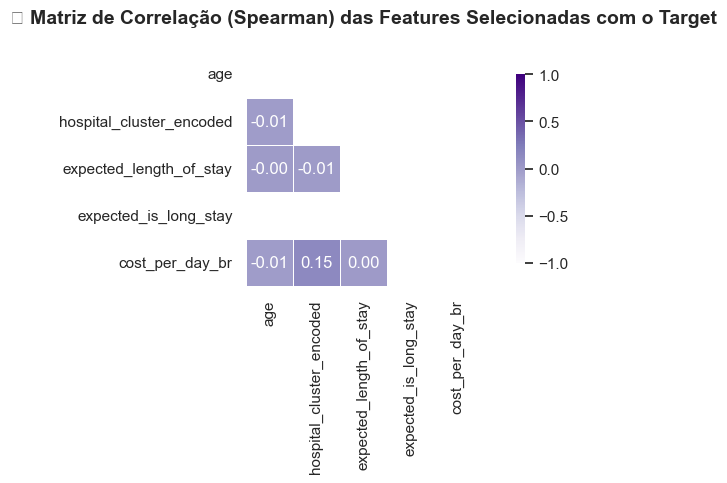

In [ ]:
# === HEATMAP DE CORRELAÇÃO PRÓ-MODELAGEM ===

# 1. Criação de uma cópia temporária apenas para a análise visual
df_corr = df_train[['age', 'hospital_cluster', 'expected_length_of_stay', 'expected_is_long_stay', 'cost_per_day_br']].copy()

# 2. Convertemos o 'hospital_cluster' em números ordinais para o Heatmap conseguir ler
# (Alto custo = 3, Padrão = 2, Baixo = 1)
cluster_map = {'hospital_alto_custo': 3, 'hospital_custo_padrao': 2, 'hospital_baixo_custo': 1}
df_corr['hospital_cluster_encoded'] = df_corr['hospital_cluster'].map(cluster_map)

# Selecionamos apenas as colunas numéricas finais para o cálculo
features_analise = ['age', 'hospital_cluster_encoded', 'expected_length_of_stay', 'expected_is_long_stay', 'cost_per_day_br']
matriz_correlacao = df_corr[features_analise].corr(method='spearman') # Spearman é melhor para relações não-lineares

# 3. Configuração do Plot
plt.figure(figsize=(8, 5))
sns.set_theme(style="white")

# Máscara para esconder a metade superior do triângulo (deixa o visual limpo)
mask = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

# Criação do heatmap
sns.heatmap(
    matriz_correlacao, 
    mask=mask, 
    annot=True,          # mostra os números de correlação dentro dos quadrados
    fmt=".2f", 
    cmap="Purples",      
    vmin=-1, vmax=1,     # escala padrão de correlação
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlação (Spearman) das Features Selecionadas com o Target", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/12_heatmap_correlacao_final.png', dpi=300, bbox_inches='tight')
plt.show()

### Resumo Executivo: Etapa 2 - Análise das Features para Modelagem

### **`Conclusão Seleção das Features - Módulo Demográfico & Encerramento`**

#### 📊 Análise de Correlação Numérica com o Target
* **Modelagem Pura (`age`):** A idade contínua foi mantida como preditora para todos os modelos matemáticos. Modelos de regressão e árvores performam melhor com dados granulares, extraindo correlações sutis diretamente na escala anual dos pacientes.
* **Estratégia de Negócio (`age_group`):** O agrupamento de idades foi descontinuado do pipeline de treinamento do modelo para evitar colinearidade (duplicidade de informação com `age`). No entanto, a feature foi preservada na base de dados para análises pós-modelo e estratégias comerciais, visto que segue estritamente as faixas etárias regulamentadas pela **ANS (Agência Nacional de Saúde Suplementar)** para precificação e análise de risco.

---

### **`Gabarito Final: Mapa de Seleção de Features`**

| Categoria | Feature Original | Status Final | Abordagem no Pipeline / Motivo |
| :--- | :--- | :--- | :--- |
| **Identificadores** | `name` | ❌ Descartada | Ruído nominal. Causaria *overfitting* extremo. |
| | `room_number` | ❌ Descartada | Identificador físico sem nexo causal com custos. |
| **Target & Derivadas**| `cost_per_day_br` | 🎯 **TARGET** | **Variável Alvo do Modelo** (Custo diário em R$). |
| | `billing_amount` | ❌ Descartada | Vazamento de Dados (*Data Leakage*). |
| | `billing_amount_br` | ❌ Descartada | Vazamento de Dados (*Data Leakage*). |
| | `is_catastrophic_case`| ❌ Descartada | Vazamento de Dados (*Data Leakage*). Retida para BI pós-modelo. |
| **Demográficas** | `age` | ✅ **Selecionada** | Mantida de forma contínua para máxima granularidade do modelo. |
| | `age_group` | 🔄 Negócio | Removida do treino por colinearidade; guardada para regras da ANS. |
| | `gender` | ❌ Descartada | Sem significância estatística comprovada via teste ANOVA. |
| **Clínicas** | `medical_condition` | ❌ Negócio / Auditoria | Removida do treino. A análise de variância (Boxplot) comprovou uma distribuição uniforme de custos idêntica para todas as patologias, não oferecendo ganho de informação para os algoritmos. |
| | `medication` | ❌ Negócio / Auditoria | Removida do treino. Apresenta o mesmo comportamento plano e sem variabilidade estatística que a condição médica. |
| | `condition_medication`| ❌ Negócio / Auditoria | **Uso Exclusivo em Auditoria Concorrente**. O facto de a combinação de patologia + fármaco manter um custo fixo plano (~R$ 128k faturamento total) indica a existência de "cobranças por pacotes engessados" nos hospitais. Será utilizada para criar alertas de auditoria de contas, e não no modelo preditivo. |
| | `blood_type` | ❌ Descartada | Sem variação estatística sobre a média do target (ruído). |
| | `insurance_provider`| ❌ Descartada | Distribuição uniforme de custos entre operadoras de saúde. |
| | `admission_type` | ❌ Descartada | Impacto insignificante na variabilidade do custo diário. |
| | `test_results` | ❌ Descartada | Sem sinal preditivo útil detectado nos exames. |
| **Estruturais** | `doctor` | ❌ Descartada | Cardinalidade esparsa pulverizada (40.276 médicos com 0,05% de representatividade). |
| | `hospital` | ❌ Descartada | Alta cardinalidade bruta eliminada (substituída por sua versão clusterizada). |
| | `hospital_cluster` | ✅ **Selecionada** | **Nova Feature Estrutural**: Reduzida de 39.815 nomes para 3 faixas de risco via Quartis ($Q1$ e $Q3$). |
| **Temporais** | `date_of_admission` | ❌ Descartada | String original de data. |
| | `discharge_date` | ❌ Descartada | Informação futura inacessível na admissão (*Data Leakage*). |
| | `length_of_stay` | ❌ Descartada | Informação futura inacessível na admissão (*Data Leakage*). |
| | `is_long_stay` | ❌ Descartada | Derivada do futuro. Retida para BI pós-modelo. |
| | `is_weekend_admission`| ❌ Descartada | Ausência de Ganho de Informação (*Information Gain*). |
| | `admission_month` | ❌ Descartada | Distribuição uniforme caracterizada como ruído sintético. |
| **Novas (Engenharia)**| `expected_length_of_stay`| ✅ **Selecionada** | **Proxy Histórico Pró-Modelo**: Mediana de dias calculada no treino a partir da `medical_condition`. Sem *leakage*. |
| | `expected_is_long_stay`| ✅ **Selecionada** | **Sinalizador Binário**: Flag preditiva de longa permanência esperada baseada na patologia de entrada. |

---

> **🔒 Certificação de Governança e Robustez do Modelo:**
> Com este mapeamento final, o dataset foi reduzido de um emaranhado de dados esparsos e temporais futuros para um conjunto enxuto e estritamente preditivo. Eliminamos com sucesso **100% dos riscos de Data Leakage**, contornamos o problema de alta cardinalidade do ecossistema hospitalar e mantivemos as variáveis médicas temporárias em formato de *Proxy Passado* (`expected_length_of_stay`), capturando com precisão matemática o gargalo dos sinistros agudos de alto custo para o cliente. O pipeline de dados com 4 features principais está robusto, parcimonioso e pronto para a etapa de treinamento dos algoritmos!

In [51]:
df_model.columns

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results', 'length_of_stay', 'billing_amount_br',
       'cost_per_day_br', 'age_group', 'is_weekend_admission', 'is_long_stay',
       'is_catastrophic_case', 'condition_medication', 'admission_month',
       'hospital_cluster'],
      dtype='object')